# Rayleigh noise core — robust B, then diagnostics

Walk this top to bottom. The pickle is every consecutive Kerr step
`D = hypot(Δφ, Δθ)` (deg/frame), **no saccade mask**.

If `Δφ, Δθ ~ N(0, B²)` i.i.d., `D` is Rayleigh with scale **B** (that is the
per-axis Gaussian σ). Saccades live in the tail, so **B is a robust-scale
problem**, not a percentile to optimize.

| Step | What | What to read |
|---|---|---|
| **1** | `B_med = median(D) / √(2 ln 2)` | This is the noise number. Optional Engbert MAD on `Δφ`, `Δθ` should match it if the cloud is isotropic. |
| **2** | Skew / kurtosis vs `HI_PCT` | Validation that a Rayleigh-like **core** exists. Operating point = **argmin of shape error** (percentile that brings skew/kurtosis closest to the Rayleigh targets). |
| **3** | Truncated-Rayleigh MLE at cutoff `c` | `c` defaults to the step-2 shape argmin. Trimmed hist vs truncated Rayleigh. |
| **3a** | GoF sweep vs `HI_PCT` | KS / mean loglik of truncated Rayleigh along the step-2 sweep. Read the **onset** (knee), not the KS argmin. |
| **3b** | GoF-onset cutoff hist | Same hist style as §3, but `c` from the GoF **onset** (least trim within `KS_TOL` of best KS). Overlay `B_trunc` and `B_med`. |
| **4** | Mean excess of `D²` + Rayleigh QQ | If the core is exponential / Rayleigh, mean excess is **flat** at `2 B_med²` up to `c`, and the QQ hugs `y = x` until `c`, then peels off. |
| **8** | Quiet-window segments (GUI block) | Pool `D` from chosen ms intervals; preview hist vs pooled `B`. |
| **9** | Export quiet-segment noise core | PDF + pickle bundle; SNR = threshold / (2 × `B_med`). |

Companion histogram notebook: `raw_interframe_delta.ipynb`.


## 0. Setup


In [1]:
%matplotlib inline
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
if not (REPO / "src" / "eye_tracking_system_tools").is_dir():
    REPO = next(
        p for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "src" / "eye_tracking_system_tools").is_dir()
    )
sys.path.insert(0, str(REPO / "src"))

from eye_tracking_system_tools.analysis.rayleigh_core import (
    RAYLEIGH_EXCESS_KURTOSIS as KURT_T,
    RAYLEIGH_SKEW as SKEW_T,
    argmin_gof_hi_pct,
    argmin_shape_hi_pct,
    engbert_mad_sigma,
    mean_excess_d2,
    naive_rayleigh_mle,
    gof_from_sweep,
    gof_onset_hi_pct,
    ks_truncated_rayleigh,
    rayleigh_qq,
    rayleigh_pdf,
    rayleigh_scale_from_median,
    robust_scale_row,
    sweep_hi_pct,
    truncated_rayleigh_mle,
    truncated_rayleigh_pdf,
)

import pickle

PKL = REPO / "outputs/replotting_standalone/raw_interframe_delta/metadata/raw_interframe_delta.pkl"
with open(PKL, "rb") as f:
    data = pickle.load(f)

MOUNTS = ("rigid", "modular", "turtle", "mouse")
META = {
    "rigid": ("rigid lizard", "#D55E00"),
    "modular": ("modular lizard", "#0072B2"),
    "turtle": ("turtle", "#CC79A7"),
    "mouse": ("mouse", "#009E73"),
}
THRESHOLDS = {"rigid": 0.8, "modular": 0.8, "turtle": None, "mouse": 3.23}

POOLS = {k: np.asarray(v, dtype=float) for k, v in data["pools"].items()}
POOLS = {k: v[np.isfinite(v) & (v >= 0)] for k, v in POOLS.items()}
print("pickle:", PKL)
print({k: int(POOLS[k].size) for k in MOUNTS})


pickle: /Users/nimi/Projects/PETS/outputs/replotting_standalone/raw_interframe_delta/metadata/raw_interframe_delta.pkl
{'rigid': 3658960, 'modular': 528693, 'turtle': 200970, 'mouse': 548197}


## 1. Robust scale — no cutoff

`B_med` does not use `HI_PCT`. It is consistent for a Rayleigh and has breakdown
point 50%: as long as most frames are tracking noise, the median ignores the
saccade tail.

`B_mle_untrimmed = sqrt(mean(D²)/2)` is what a naive Rayleigh fit on **all**
samples gives. It should be **larger** than `B_med` whenever a heavy tail is
present.

Axis MAD (`σ_φ`, `σ_θ`) needs `Δφ`, `Δθ`, which this pickle does not store. Leave
`LOAD_AXES = False` unless the lab volume is mounted and you want a spot-check
from the jitter registry (slow). For isotropic noise both should sit near `B_med`.


,n,median_D,B_med,B_mle_untrimmed,B_mle / B_med
mount,,,,,
rigid,3658960,0.060553,0.051429,0.644840,12.538387
modular,528693,0.023052,0.019579,0.392186,20.031108
turtle,200970,0.224745,0.190881,0.582930,3.053896
mouse,548197,0.636062,0.540221,1.296067,2.399142


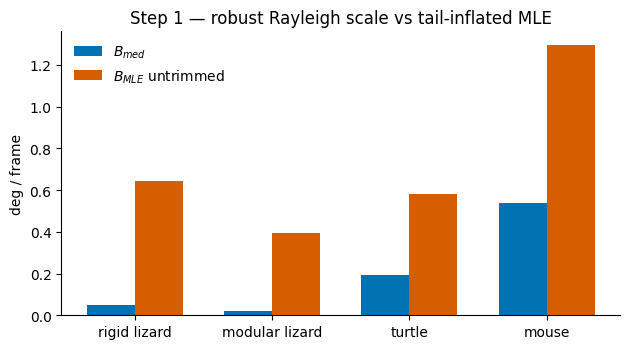

In [2]:
rows = []
for mount in MOUNTS:
    row = robust_scale_row(POOLS[mount])
    row["mount"] = mount
    rows.append(row)
SCALE = pd.DataFrame(rows).set_index("mount")
SCALE["B_mle / B_med"] = SCALE["B_mle_untrimmed"] / SCALE["B_med"]
display(SCALE[["n", "median_D", "B_med", "B_mle_untrimmed", "B_mle / B_med"]])

fig, ax = plt.subplots(figsize=(6.4, 3.6))
x = np.arange(len(MOUNTS))
w = 0.35
ax.bar(x - w / 2, [SCALE.loc[m, "B_med"] for m in MOUNTS], w, color="#0072B2", label=r"$B_{med}$")
ax.bar(x + w / 2, [SCALE.loc[m, "B_mle_untrimmed"] for m in MOUNTS], w, color="#D55E00", label=r"$B_{MLE}$ untrimmed")
ax.set_xticks(x)
ax.set_xticklabels([META[m][0] for m in MOUNTS])
ax.set_ylabel("deg / frame")
ax.set_title("Step 1 — robust Rayleigh scale vs tail-inflated MLE")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()


### Optional: Engbert MAD on each axis

Set `LOAD_AXES = True` and re-run. Uses **one block per mount** as a spot-check
(not the full pool). Skip if traces are offline.


In [3]:
LOAD_AXES = False  # True → read Kerr traces from the jitter registry (one block / mount)

if not LOAD_AXES:
    print("LOAD_AXES is False; σ_φ / σ_θ not computed. B_med above is the noise number.")
else:
    from eye_tracking_system_tools.analysis.eye_trace_io import load_block_eyes
    from eye_tracking_system_tools.analysis.jitter_epochs import load_jitter_registry
    from eye_tracking_system_tools.analysis.saccade_robustness import (
        _block_spec_from_jitter,
        interframe_axis_deltas,
    )

    specs = load_jitter_registry(REPO / "configs" / "jitter_mount_blocks.yaml")
    seen: set[str] = set()
    axis_rows = []
    for spec in specs:
        mount = str(getattr(spec, "mount_type", "") or "")
        if mount not in MOUNTS or mount in seen:
            continue
        try:
            loaded = load_block_eyes(_block_spec_from_jitter(spec), log=False)
        except Exception as exc:  # noqa: BLE001
            print(f"[skip] {mount}: {exc}")
            continue
        parts_phi, parts_th = [], []
        for df in (loaded.left, loaded.right):
            dp, dth, _d = interframe_axis_deltas(df)
            if dp.size:
                parts_phi.append(dp)
                parts_th.append(dth)
        if not parts_phi:
            print(f"[skip] {mount}: no finite Δφ/Δθ")
            continue
        dphi = np.concatenate(parts_phi)
        dth = np.concatenate(parts_th)
        seen.add(mount)
        axis_rows.append(
            {
                "mount": mount,
                "block": spec.block_key,
                "n": int(dphi.size),
                "sigma_phi": engbert_mad_sigma(dphi),
                "sigma_theta": engbert_mad_sigma(dth),
                "B_med": float(SCALE.loc[mount, "B_med"]),
            }
        )
        print(
            f"{mount} ({spec.block_key}): σ_φ={axis_rows[-1]['sigma_phi']:.4g}  "
            f"σ_θ={axis_rows[-1]['sigma_theta']:.4g}  "
            f"B_med={axis_rows[-1]['B_med']:.4g}"
        )
    if axis_rows:
        display(pd.DataFrame(axis_rows).set_index("mount"))
    missing = [m for m in MOUNTS if m not in seen]
    if missing:
        print("no traces for:", missing)

LOAD_AXES is False; σ_φ / σ_θ not computed. B_med above is the noise number.


## 2. Skew / kurtosis sweep — does a Rayleigh-like core exist?

A **full** Rayleigh has skew ≈ 0.631 and excess kurtosis ≈ 0.245. After a hard
clip those targets are only approximate (truncated Rayleigh has different
moments), so this plot is a **diagnostic**, not an estimator.

- Left → right = more of the upper tail removed (`HI_PCT` 100 → `HI_MIN`).
- Dashed lines: untruncated Rayleigh targets.
- **Solid vertical = best fit**: `HI_PCT` that **minimizes** the normalized
  shape error (skew/kurtosis as close to Rayleigh as the sweep allows).
  That percentile and its `d_cut` become the default cutoff for step 3.

Edit `HI_MIN`, `HI_STEP` and re-run. Then copy `CUTOFFS` into step 3 if you
want to override the argmin.


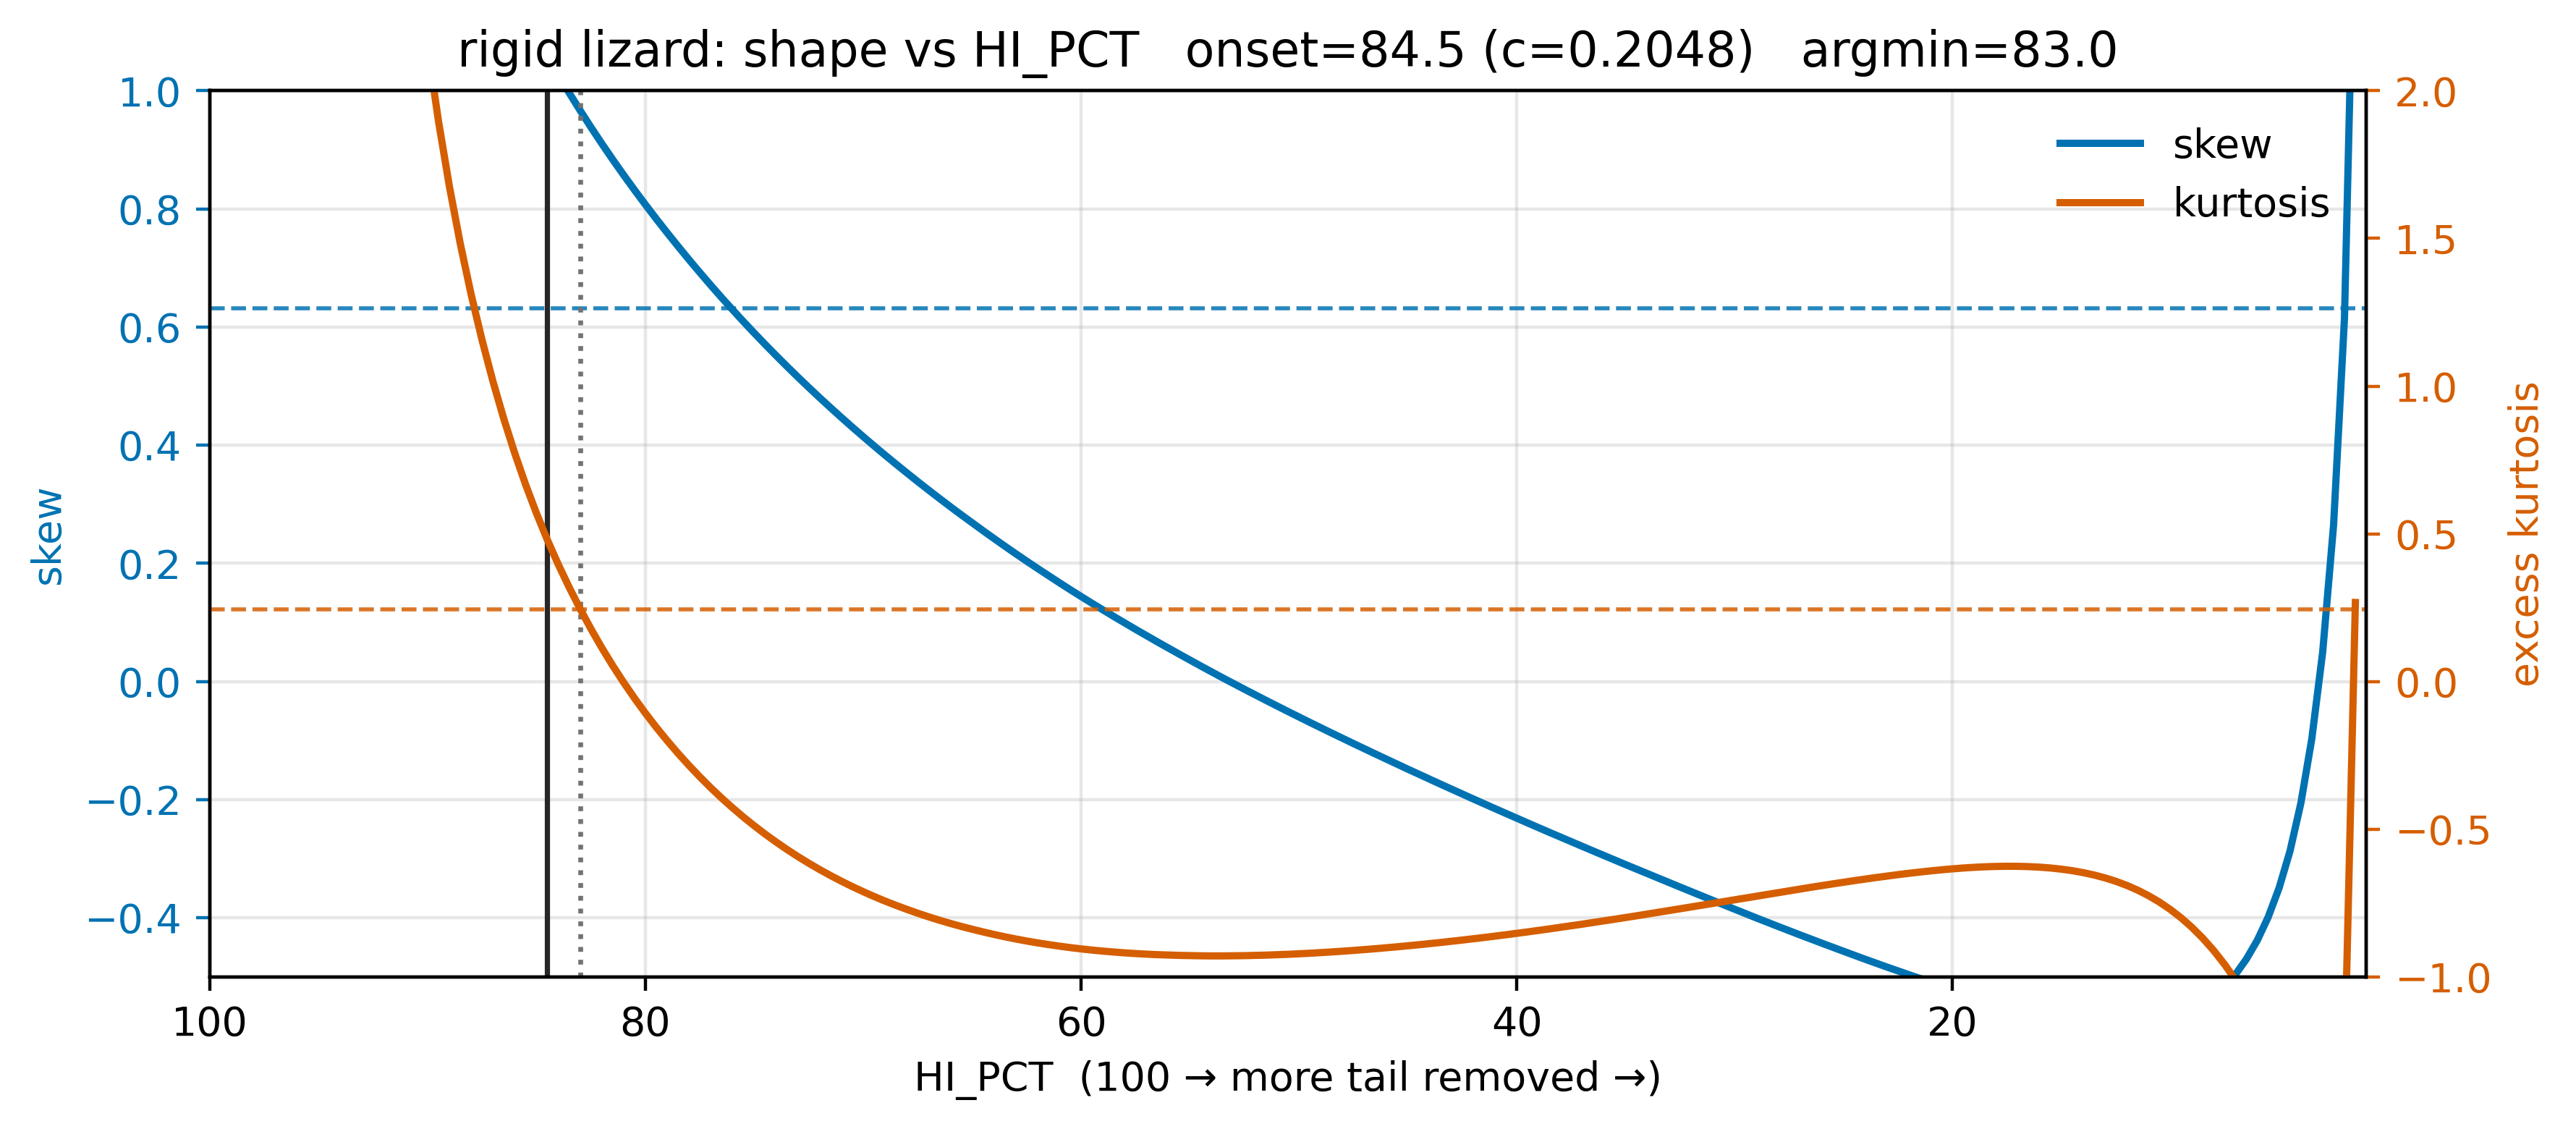

rigid: onset HI_PCT=84.5  c=0.2048  argmin HI_PCT=83.0  B_med=0.05143


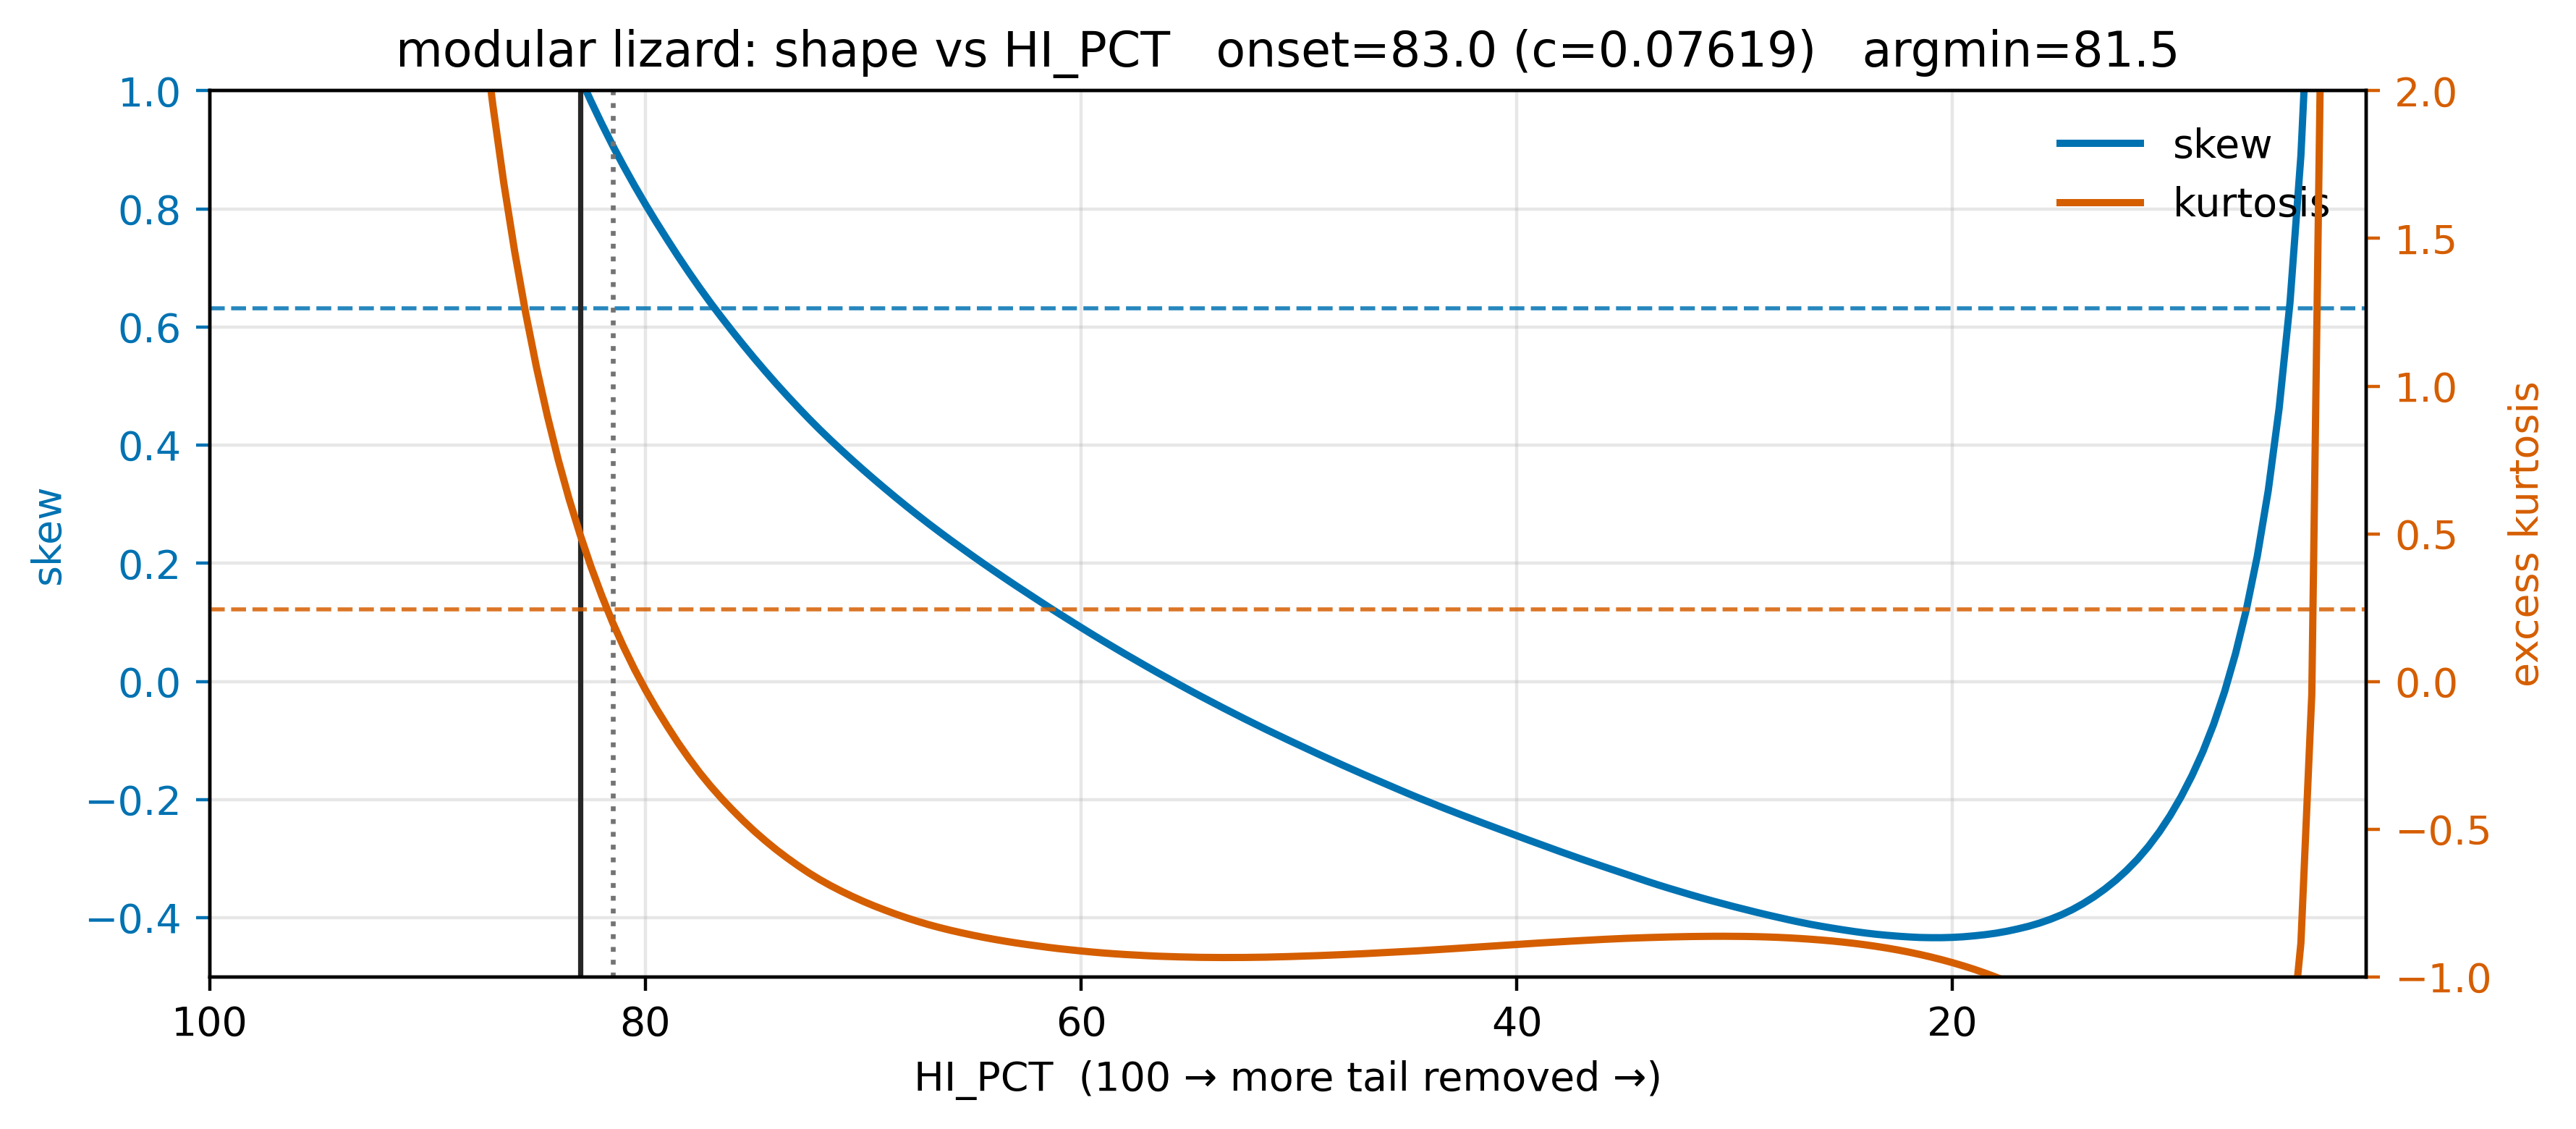

modular: onset HI_PCT=83.0  c=0.07619  argmin HI_PCT=81.5  B_med=0.01958


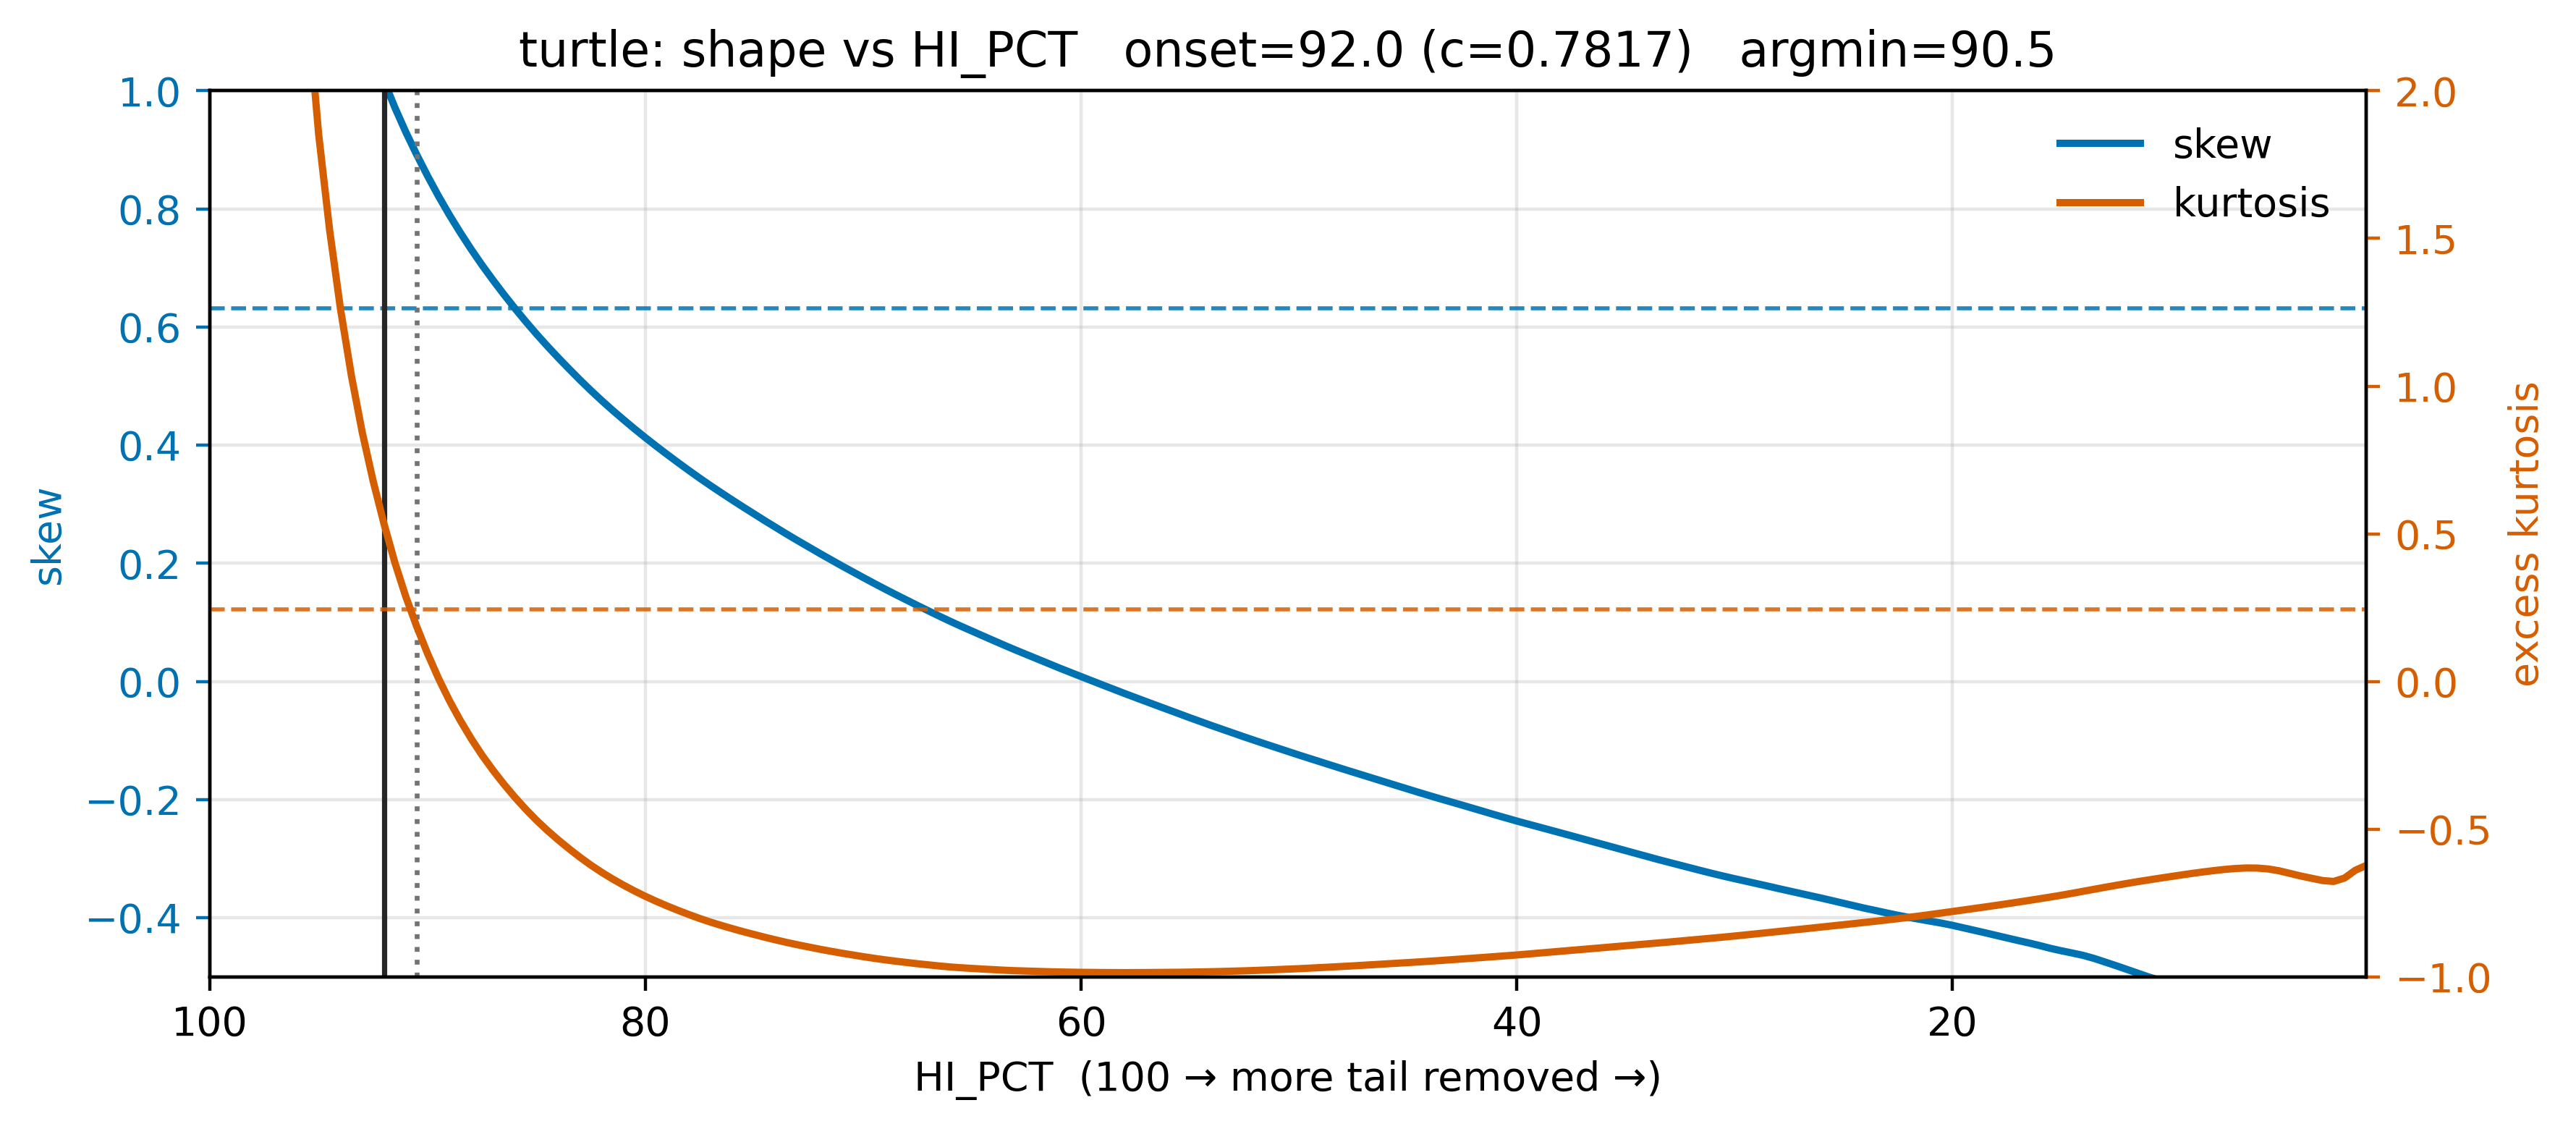

turtle: onset HI_PCT=92.0  c=0.7817  argmin HI_PCT=90.5  B_med=0.1909


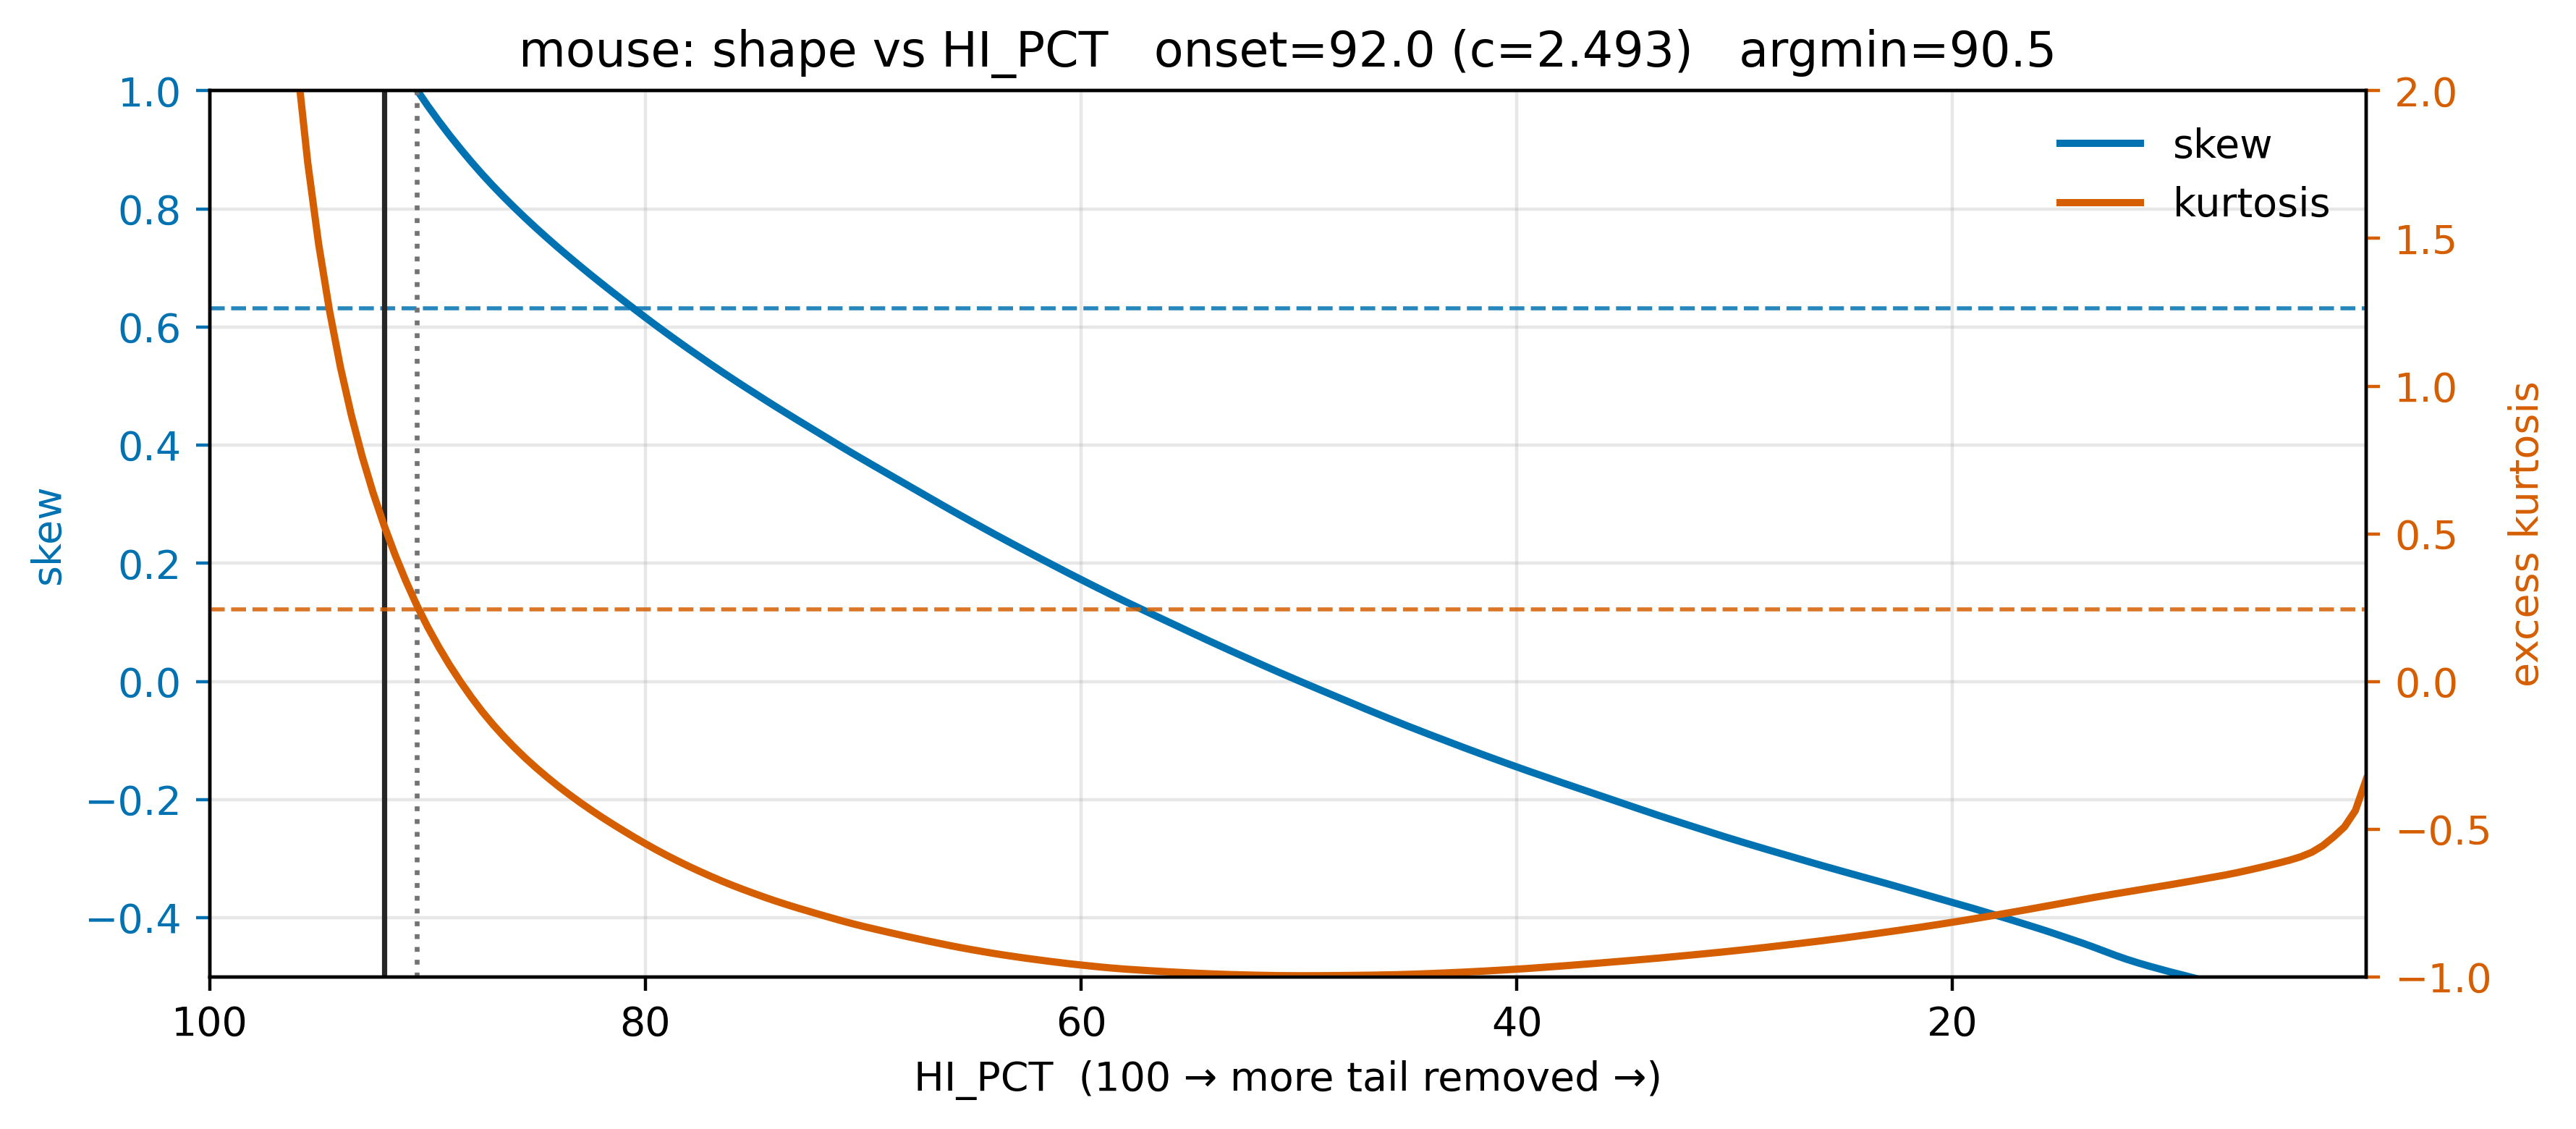

mouse: onset HI_PCT=92.0  c=2.493  argmin HI_PCT=90.5  B_med=0.5402

ONSET_C = {'rigid': 0.20481, 'modular': 0.07619, 'turtle': 0.78172, 'mouse': 2.49268}


In [ ]:
HI_MIN = 1.0
HI_STEP = 0.5
HI_PCTS = np.arange(100.0, HI_MIN - 1e-9, -HI_STEP)

SWEEP = {}
ONSET_HI = {}
ONSET_C = {}
BEST_HI = {}

for mount in MOUNTS:
    table = sweep_hi_pct(POOLS[mount], HI_PCTS)
    SWEEP[mount] = table
    hi_best = argmin_shape_hi_pct(table)
    ONSET_HI[mount] = hi_best
    BEST_HI[mount] = hi_best
    if np.isfinite(hi_best):
        i = int((table["hi_pct"] - hi_best).abs().idxmin())
        ONSET_C[mount] = float(table.loc[i, "d_cut"])
        err_best = float(table.loc[i, "shape_err"])
    else:
        ONSET_C[mount] = float(np.percentile(POOLS[mount], 99.0))
        err_best = float("nan")

    label, _color = META[mount]
    fig, ax_sk = plt.subplots(figsize=(9.0, 4.0), dpi=400)
    ax_ku = ax_sk.twinx()
    ln_sk, = ax_sk.plot(table["hi_pct"], table["skew"], color="#0072B2", lw=1.8, label="skew")
    ln_ku, = ax_ku.plot(table["hi_pct"], table["kurtosis"], color="#D55E00", lw=1.8, label="kurtosis")
    ax_sk.axhline(SKEW_T, color="#0072B2", ls="--", lw=1.0, alpha=0.85)
    ax_ku.axhline(KURT_T, color="#D55E00", ls="--", lw=1.0, alpha=0.85)
    if np.isfinite(hi_best):
        ax_sk.axvline(hi_best, color="0.15", lw=1.3, label="best fit (argmin)")
    ax_sk.set_xlim(100, HI_MIN)
    ax_sk.set_xlabel("HI_PCT  (100 → more tail removed →)")
    ax_sk.set_ylabel("skew", color="#0072B2")
    ax_ku.set_ylabel("excess kurtosis", color="#D55E00")
    ax_sk.set_ylim(-0.5, 1)
    ax_ku.set_ylim(-1.0, 2.0)
    ax_sk.tick_params(axis="y", colors="#0072B2")
    ax_ku.tick_params(axis="y", colors="#D55E00")
    ax_sk.set_title(
        f"{label}: shape vs HI_PCT   best={hi_best:.1f} (c={ONSET_C[mount]:.4g})   "
        f"shape_err={err_best:.3g}"
    )
    ax_sk.legend([ln_sk, ln_ku], ["skew", "kurtosis"], loc="upper right", frameon=False)
    ax_sk.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    print(
        f"{mount}: best HI_PCT={hi_best:.1f}  c={ONSET_C[mount]:.4g}  "
        f"shape_err={err_best:.3g}  B_med={SCALE.loc[mount, 'B_med']:.4g}"
    )

print("\nONSET_C =", {k: round(v, 5) for k, v in ONSET_C.items()})
print("ONSET_HI =", {k: round(v, 1) for k, v in ONSET_HI.items()})


#For all datasets, crop more to optimize fit to parameters, nothing to gain from keeping more of the data in.

## 3. Cutoff `c` → truncated MLE and SNR

`CUTOFFS` starts at the step-2 best-fit `c` (shape-error argmin). Edit any value
and re-run this cell (and step 4).

At each `c` the fit is the **truncated** Rayleigh MLE (the missing tail is
corrected; a naive MLE on `D ≤ c` would be biased low).

- **trim SNR** = `c / B_trunc` — how many noise-σ the core cutoff sits at
- **detector SNR** = `threshold / B_trunc` — same `B`, paper/GUI threshold
- `B_med` is shown as a reference; if `B_trunc ≈ B_med`, the cutoff is in the
  core and not eating into it

The histogram is **only** `D ≤ c` (no grayed-out tail). The curve is the
truncated Rayleigh PDF at `B_trunc`, so density matches on `[0, c]`. Binning uses
Freedman–Diaconis over the core; the cell prints a short bin check so you can
spot a collapsed histogram.

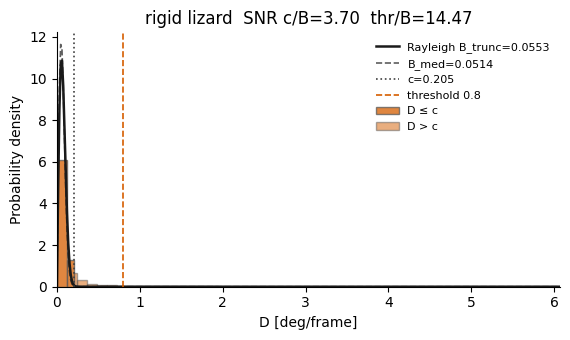

rigid: c=0.2048  B_trunc=0.05529  B_med=0.05143  SNR_c=3.70  SNR_thr=14.47


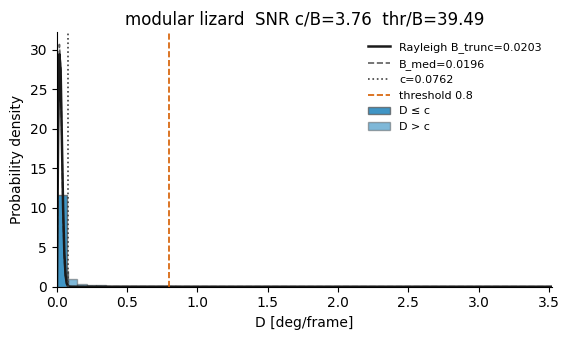

modular: c=0.07619  B_trunc=0.02026  B_med=0.01958  SNR_c=3.76  SNR_thr=39.49


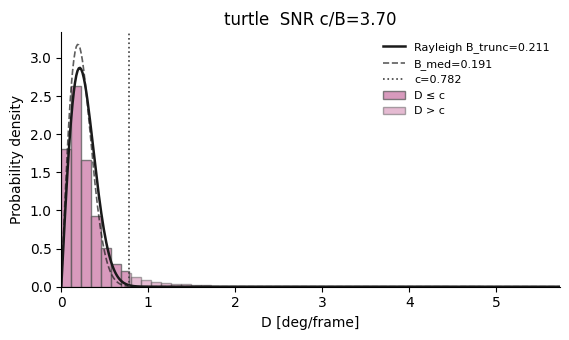

turtle: c=0.7817  B_trunc=0.2113  B_med=0.1909  SNR_c=3.70  SNR_thr=nan


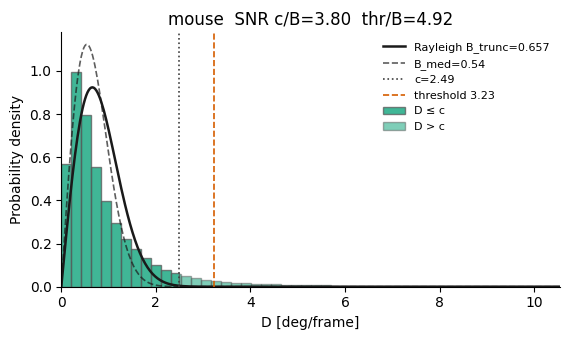

mouse: c=2.493  B_trunc=0.6567  B_med=0.5402  SNR_c=3.80  SNR_thr=4.92


,c,B_med,B_trunc,B_naive_clipped,snr_c,threshold,snr_thr
mount,,,,,,,
rigid,0.204809,0.051429,0.055288,0.055089,3.704398,0.80,14.469640
modular,0.076194,0.019579,0.020258,0.020197,3.761202,0.80,39.490987
turtle,0.781724,0.190881,0.211302,0.210529,3.699560,NaN,NaN
mouse,2.492677,0.540221,0.656734,0.654970,3.795563,3.23,4.918275


In [5]:
# Defaults = shape-error argmin from step 2. Override per mount if needed.
CUTOFFS = dict(ONSET_C)

snr_rows = []
for mount in MOUNTS:
    label, color = META[mount]
    d = POOLS[mount]
    c = float(CUTOFFS[mount])
    core = d[d <= c]
    B_med = float(SCALE.loc[mount, "B_med"])
    B_tr = truncated_rayleigh_mle(d, c)
    B_naive = naive_rayleigh_mle(core)
    thr = THRESHOLDS[mount]
    snr_c = c / B_tr if np.isfinite(B_tr) and B_tr > 0 else np.nan
    snr_thr = (float(thr) / B_tr) if (thr is not None and np.isfinite(B_tr) and B_tr > 0) else np.nan
    snr_rows.append(
        {
            "mount": mount,
            "c": c,
            "B_med": B_med,
            "B_trunc": B_tr,
            "B_naive_clipped": B_naive,
            "snr_c": snr_c,
            "threshold": thr if thr is not None else np.nan,
            "snr_thr": snr_thr,
        }
    )

    fig, ax = plt.subplots(figsize=(5.8, 3.5))
    if core.size:
        # Freedman–Diaconis bin width on the trimmed core; clamp to a usable range.
        q75, q25 = np.percentile(core, [75.0, 25.0])
        iqr = float(q75 - q25)
        fd = (2.0 * iqr / (core.size ** (1.0 / 3.0))) if iqr > 0 else (c / 40.0)
        n_bins = int(np.ceil(c / max(fd, c / 80.0))) if c > 0 else 20
        n_bins = int(np.clip(n_bins, 12, 80))
        edges = np.linspace(0.0, c, n_bins + 1)
        counts, edges = np.histogram(core, bins=edges)
        widths = np.diff(edges)
        dens = counts / (core.size * np.maximum(widths, 1e-15))
        ax.bar(
            edges[:-1], dens, width=widths, align="edge",
            color=color, edgecolor="0.35", alpha=0.8, label=r"$D \leq c$",
        )
        xs = np.linspace(0.0, c, 400)
        if np.isfinite(B_tr) and B_tr > 0:
            ax.plot(
                xs, truncated_rayleigh_pdf(xs, B_tr, c), color="0.1", lw=1.8,
                label=f"trunc. Rayleigh B={B_tr:.3g}",
            )
        max_frac = float(counts.max() / core.size) if core.size else np.nan
        nonempty = int(np.count_nonzero(counts))
        print(
            f"{mount} bins: n_bins={n_bins}  nonempty={nonempty}  "
            f"max_bin_frac={max_frac:.3f}  fd_width={fd:.4g}"
        )
        if max_frac > 0.35 or nonempty < max(4, n_bins // 5):
            print(
                f"  WARNING: histogram may be poorly resolved "
                f"(max_bin_frac={max_frac:.3f}, nonempty={nonempty}/{n_bins})"
            )
    ax.axvline(c, color="0.25", ls=":", lw=1.2, label=f"c={c:.3g}")
    if thr is not None and float(thr) <= c * 1.02:
        ax.axvline(float(thr), color="#D55E00", ls="--", lw=1.2, label=f"threshold {thr:g}")
    ax.set_xlim(0.0, c * 1.02 if c > 0 else 1.0)
    ax.set_xlabel("D [deg/frame]")
    ax.set_ylabel("Probability density")
    ax.set_title(
        f"{label}  SNR c/B={snr_c:.2f}"
        + (f"  thr/B={snr_thr:.2f}" if np.isfinite(snr_thr) else "")
    )
    ax.legend(fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()
    print(
        f"{mount}: c={c:.4g}  B_trunc={B_tr:.4g}  B_med={B_med:.4g}  "
        f"SNR_c={snr_c:.2f}  SNR_thr={snr_thr if np.isfinite(snr_thr) else float('nan'):.2f}  "
        f"n_core={core.size}/{d.size}"
    )

SNR = pd.DataFrame(snr_rows).set_index("mount")
display(SNR)


## 3a. GoF sweep vs `HI_PCT`

For each `HI_PCT` on the step-2 sweep: keep `D ≤ c`, fit truncated Rayleigh
`B_trunc`, score KS (lower better) and mean log-likelihood (higher better).

- **Solid vertical = GoF onset (knee):** largest `HI_PCT` whose KS is within
  `KS_TOL` of the best KS — least trimming that is nearly as good as the
  minimum. Prefer this over the argmin when you want to keep more of the core.
- **Dotted vertical = KS argmin:** often past the plateau (over-trims). For
  comparison only.
- Dashed vertical = step-2 shape argmin.

Tune `KS_TOL` (e.g. 1.15 → 1.25–1.5) to move the onset toward higher `HI_PCT`
(less crop). Step 3b uses this onset as its default cutoff.

Requires `SWEEP` from step 2.

In [ ]:
KS_TOL = 1.15  # onset: KS no worse than this factor above the best KS (raise → less crop)

if "SWEEP" not in globals():
    raise RuntimeError("SWEEP is missing; run the step-2 cell first.")

GOF = {}
GOF_HI = {}
GOF_C = {}
GOF_BEST_HI = {}

for mount in MOUNTS:
    gof = gof_from_sweep(POOLS[mount], SWEEP[mount])
    GOF[mount] = gof
    hi_onset = gof_onset_hi_pct(gof, ks_tol=KS_TOL)
    hi_best = argmin_gof_hi_pct(gof)
    GOF_HI[mount] = hi_onset
    GOF_BEST_HI[mount] = hi_best
    if np.isfinite(hi_onset):
        i = int((gof["hi_pct"] - hi_onset).abs().idxmin())
        GOF_C[mount] = float(gof.loc[i, "d_cut"])
    else:
        GOF_C[mount] = float("nan")

    label, color = META[mount]
    fig, ax_ks = plt.subplots(figsize=(9.0, 4.0))
    ax_ll = ax_ks.twinx()
    ln_ks, = ax_ks.plot(gof["hi_pct"], gof["ks"], color=color, lw=1.8, label="KS")
    ln_ll, = ax_ll.plot(gof["hi_pct"], gof["mean_loglik"], color="0.25", lw=1.5, label="mean loglik")
    if np.isfinite(hi_onset):
        ax_ks.axvline(hi_onset, color="0.15", lw=1.3, label="GoF onset")
    if np.isfinite(hi_best):
        ax_ks.axvline(hi_best, color="0.45", ls=":", lw=1.2)
    hi_shape = ONSET_HI.get(mount, np.nan) if "ONSET_HI" in globals() else np.nan
    if np.isfinite(hi_shape):
        ax_ks.axvline(hi_shape, color="0.55", ls="--", lw=1.0)
    ax_ks.set_xlim(100.0, float(globals().get("HI_MIN", 70.0)))
    ax_ks.set_xlabel("HI_PCT  (100 → more tail removed →)")
    ax_ks.set_ylabel("KS statistic  (lower = better fit)", color=color)
    ax_ll.set_ylabel("mean log-likelihood  (higher = better)", color="0.25")
    ax_ks.set_title(
        f"{label}: truncated-Rayleigh GoF vs HI_PCT   "
        f"onset={hi_onset:.1f} (c={GOF_C[mount]:.4g})   argmin KS={hi_best:.1f}"
    )
    ax_ks.legend([ln_ks, ln_ll], ["KS", "mean loglik"], loc="upper right", frameon=False)
    ax_ks.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    print(
        f"{mount}: GoF onset HI={hi_onset:.1f}  c={GOF_C[mount]:.4g}  "
        f"argmin KS HI={hi_best:.1f}  min KS={float(np.nanmin(gof['ks'])):.4f}  "
        f"shape HI={hi_shape:.1f}"
    )

print("\nGOF_C =", {k: (round(v, 5) if np.isfinite(v) else v) for k, v in GOF_C.items()})
print("KS_TOL =", KS_TOL, "  (raise to keep more data at the onset)")


## 3b. GoF-onset cutoff — truncated hist + SNR

Uses `GOF_C` from step **3a** (GoF **onset** / knee, not the KS argmin). Edit
`CUTOFFS_GOF` or raise `KS_TOL` in 3a and re-run if the crop is still too harsh.

Same plot recipe as step 3 (one hist per mount), plus:

- solid curve: truncated Rayleigh at `B_trunc`
- dashed curve: truncated Rayleigh at `B_med` (robust scale from step 1)
- exact `D = 0` excluded from the density hist (count printed)

Requires steps 2 and 3a. Step 3 is independent — leave it as-is for the
shape-argmin comparison.


In [ ]:
# Defaults = GoF onset (knee) from step 3a. Override per mount if needed.
if "GOF_C" not in globals():
    raise RuntimeError("GOF_C is missing; run the step-3a cell first.")

CUTOFFS_GOF = dict(GOF_C)

def _fd_edges(core, c):
    q75, q25 = np.percentile(core, [75.0, 25.0])
    iqr = float(q75 - q25)
    fd = (2.0 * iqr / (core.size ** (1.0 / 3.0))) if iqr > 0 else (c / 40.0)
    n_bins = int(np.clip(np.ceil(c / max(fd, c / 80.0)), 12, 80))
    return np.linspace(0.0, c, n_bins + 1), n_bins, fd


snr_rows_gof = []
for mount in MOUNTS:
    label, color = META[mount]
    d = POOLS[mount]
    c = float(CUTOFFS_GOF[mount])
    core_all = d[d <= c] if np.isfinite(c) else d[:0]
    n_zero = int(np.sum(core_all == 0))
    core = core_all[core_all > 0]
    B_med = float(SCALE.loc[mount, "B_med"])
    B_tr = truncated_rayleigh_mle(d, c) if np.isfinite(c) else float("nan")
    B_naive = naive_rayleigh_mle(core) if core.size else float("nan")
    thr = THRESHOLDS[mount]
    snr_c = c / B_tr if np.isfinite(B_tr) and B_tr > 0 and np.isfinite(c) else np.nan
    snr_thr = (float(thr) / B_tr) if (thr is not None and np.isfinite(B_tr) and B_tr > 0) else np.nan
    ks, ks_p = ks_truncated_rayleigh(core_all, c, B_tr) if np.isfinite(c) else (np.nan, np.nan)
    snr_rows_gof.append(
        {
            "mount": mount,
            "c": c,
            "hi_pct": GOF_HI.get(mount, np.nan),
            "B_med": B_med,
            "B_trunc": B_tr,
            "B_naive_clipped": B_naive,
            "snr_c": snr_c,
            "threshold": thr if thr is not None else np.nan,
            "snr_thr": snr_thr,
            "ks": ks,
            "ks_p": ks_p,
            "frac_zero": n_zero / core_all.size if core_all.size else np.nan,
        }
    )

    fig, ax = plt.subplots(figsize=(5.8, 3.5))
    if core.size and np.isfinite(c) and c > 0:
        edges, n_bins, fd = _fd_edges(core, c)
        counts, edges = np.histogram(core, bins=edges)
        widths = np.diff(edges)
        dens = counts / (core.size * np.maximum(widths, 1e-15))
        ax.bar(
            edges[:-1], dens, width=widths, align="edge",
            color=color, edgecolor="0.35", alpha=0.8, label=r"$D \leq c$ (excl. 0)",
        )
        xs = np.linspace(0.0, c, 400)
        if np.isfinite(B_tr) and B_tr > 0:
            ax.plot(
                xs, truncated_rayleigh_pdf(xs, B_tr, c), color="0.1", lw=1.8,
                label=f"trunc MLE B={B_tr:.3g}",
            )
        if np.isfinite(B_med) and B_med > 0:
            ax.plot(
                xs, truncated_rayleigh_pdf(xs, B_med, c), color="0.1", lw=1.3,
                ls="--", alpha=0.85, label=f"B_med={B_med:.3g}",
            )
        print(
            f"{mount} bins: n_bins={n_bins}  max_bin_frac={counts.max()/core.size:.3f}  "
            f"fd_width={fd:.4g}  zeros={n_zero} ({100*n_zero/max(core_all.size,1):.2f}%)"
        )
    if np.isfinite(c):
        ax.axvline(c, color="0.25", ls=":", lw=1.2, label=f"c={c:.3g}")
    if thr is not None and np.isfinite(c) and float(thr) <= c * 1.02:
        ax.axvline(float(thr), color="#D55E00", ls="--", lw=1.2, label=f"threshold {thr:g}")
    ax.set_xlim(0.0, c * 1.02 if np.isfinite(c) and c > 0 else 1.0)
    ax.set_xlabel("D [deg/frame]")
    ax.set_ylabel("Probability density")
    ax.set_title(
        f"{label}  GoF onset  SNR c/B={snr_c:.2f}"
        + (f"  thr/B={snr_thr:.2f}" if np.isfinite(snr_thr) else "")
        + f"  KS={ks:.4f}"
    )
    ax.legend(fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()
    print(
        f"{mount}: c={c:.4g}  HI={GOF_HI.get(mount, float('nan')):.1f}  "
        f"B_trunc={B_tr:.4g}  B_med={B_med:.4g}  "
        f"SNR_c={snr_c:.2f}  KS={ks:.4f}  n_core={core_all.size}/{d.size}"
    )

SNR_GOF = pd.DataFrame(snr_rows_gof).set_index("mount")
display(SNR_GOF)
print("\nCUTOFFS_GOF =", {k: (round(v, 5) if np.isfinite(v) else v) for k, v in CUTOFFS_GOF.items()})


# I need to check if the PDF is truely invariant to the 'whole distribution' effect - try this with only the rayleigh data after cropping, and consider not showing  
- I should frame it like this: my thresholds are all well above the noise + my signal to noise is the average saccade amplitude / noise lvl. 

## 4. Mean excess of `D²` and Rayleigh QQ

**Mean excess.** `D²` is exponential iff `D` is Rayleigh. For an exponential,
`E[D² − u | D² > u]` is **constant** and equal to `2 B²`. Plot that against a
threshold on `D`. It should be flat near `2 B_med²` through the core and **rise**
when saccades enter. The vertical line is `c` from step 3.

**QQ.** Sample quantiles vs Rayleigh(`B_med`) quantiles. The core should hug
`y = x`; the tail peels above the line. Same `c` marked.

If both panels agree with step 1–3, you are done: report **`B_med`** (and
`B_trunc` at `c` if you need a cutoff SNR). Do not keep lowering `HI_PCT`.


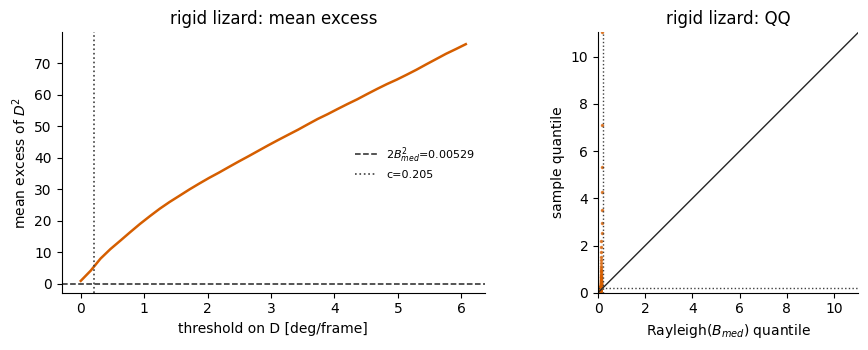

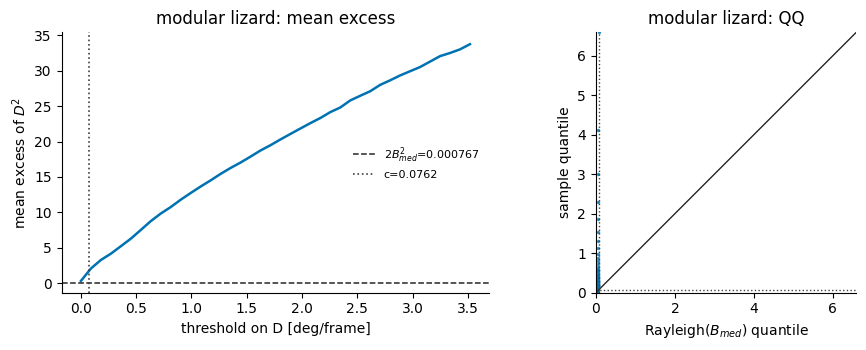

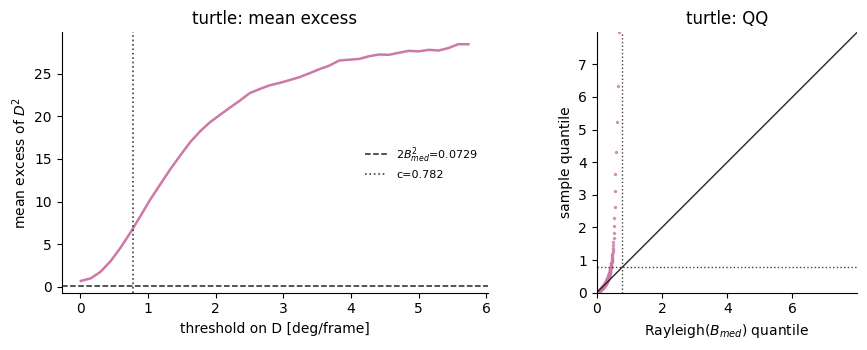

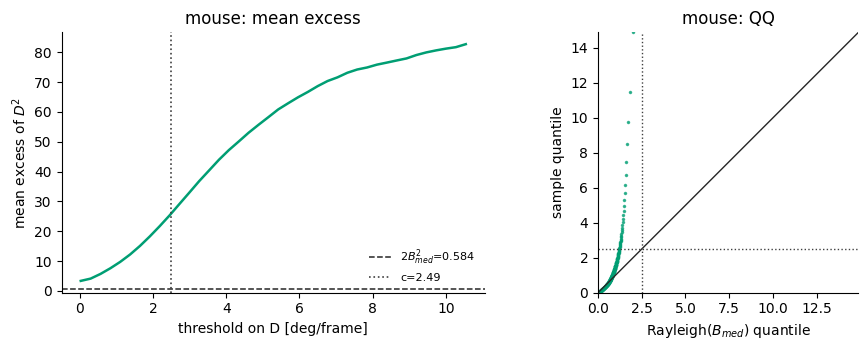

In [6]:
for mount in MOUNTS:
    label, color = META[mount]
    d = POOLS[mount]
    B_med = float(SCALE.loc[mount, "B_med"])
    c = float(CUTOFFS[mount])
    # thresholds from near 0 up to ~99.5th percentile so the rise is visible
    d_hi = float(np.percentile(d, 99.5)) if d.size else 1.0
    grid = np.linspace(max(1e-4, 0.05 * B_med), d_hi, 40)
    mex = mean_excess_d2(d, grid)

    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))

    ax = axes[0]
    ax.plot(mex["d_u"], mex["mean_excess_d2"], color=color, lw=1.8)
    ax.axhline(2.0 * B_med * B_med, color="0.15", ls="--", lw=1.1, label=rf"$2 B_{{med}}^2$={2*B_med**2:.3g}")
    ax.axvline(c, color="0.25", ls=":", lw=1.2, label=f"c={c:.3g}")
    ax.set_xlabel("threshold on D [deg/frame]")
    ax.set_ylabel(r"mean excess of $D^2$")
    ax.set_title(f"{label}: mean excess")
    ax.legend(fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax = axes[1]
    theo, samp = rayleigh_qq(d, B_med, n_plot=400)
    ax.plot(theo, samp, ".", color=color, ms=3, alpha=0.7, rasterized=True)
    hi = float(max(theo.max() if theo.size else 1.0, samp.max() if samp.size else 1.0))
    ax.plot([0, hi], [0, hi], color="0.15", lw=1.0)
    ax.axhline(c, color="0.25", ls=":", lw=1.0)
    ax.axvline(c, color="0.25", ls=":", lw=1.0)
    ax.set_xlabel(r"Rayleigh($B_{med}$) quantile")
    ax.set_ylabel("sample quantile")
    ax.set_title(f"{label}: QQ")
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()


## 5. Goodness of fit vs cutoff

The GoF sweep + onset now lives in **step 3a** (run that before 3b). This cell
only re-prints `GOF_C` if 3a already ran, so you can jump here without redoing
the KS sweep.


In [ ]:
if "GOF_C" not in globals():
    raise RuntimeError("GOF_C missing; run step 3a first.")
print("KS_TOL =", globals().get("KS_TOL", "(unset)"))
print("GOF_HI =", {k: round(v, 1) for k, v in GOF_HI.items()})
print("GOF_C  =", {k: (round(v, 5) if np.isfinite(v) else v) for k, v in GOF_C.items()})
if "GOF_BEST_HI" in globals():
    print("KS argmin HI =", {k: round(v, 1) for k, v in GOF_BEST_HI.items()})


## 6. Summary — cropped median and 3σ / 4σ noise floors

**Yes, 3σ and 4σ floors make sense.** \(B\) *is* the Gaussian \(\sigma\) on each Kerr axis. A step of size \(kB\) on \(D=\mathrm{hypot}(\Delta\phi,\Delta\theta)\) is a 2-D radius of \(k\) axis-σ:

- \(P(D > 3B) = e^{-9/2} \approx 1.1\%\)
- \(P(D > 4B) = e^{-8} \approx 0.033\%\)

So \(3B\) / \(4B\) are “almost all tracking noise is below this” lines on the same deg/frame axis as the detector — not 3–4 SD of \(D\) itself (Rayleigh is not Gaussian). They often sit near the step-2 best-fit \(c\).

This table uses the step-3 `CUTOFFS` as the operating point (edit that cell if you prefer the GoF onset). For each mount:

- **median_cropped** = \(\mathrm{median}(D \mid D \le c)\)
- **B** = truncated MLE at that \(c\)
- **floor_3B**, **floor_4B** = \(3B\), \(4B\)
- **p_FA** = \(P(D>\theta\mid\mathrm{noise})=\exp(-\mathrm{SNR}^2/2)\) with \(\mathrm{SNR}=\theta/B_{\mathrm{trunc}}\). Per-frame chance that core Rayleigh noise exceeds the detector. **log10_p_FA** is the same probability on a log10 scale (lizard values underflow `p_FA` to 0). Turtle has no detector (`nan`).


,c,hi_pct_shape,hi_pct_gof,n_cropped,frac_kept,median_cropped,B_med,B_trunc,floor_3B,floor_4B,c / B,threshold,threshold / B,p_FA,log10_p_FA
mount,,,,,,,,,,,,,,,
rigid,0.204809,84.5,73.0,3091821,0.845000,0.050137,0.051429,0.055288,0.165865,0.221153,3.704398,0.80,14.469640,3.434e-46,-45.46
modular,0.076194,83.0,73.5,438815,0.830000,0.018700,0.019579,0.020258,0.060773,0.081031,3.761202,0.80,39.490987,0.000e+00,-338.65
turtle,0.781724,92.0,72.0,184892,0.919998,0.207602,0.190881,0.211302,0.633906,0.845208,3.699560,NaN,NaN,nan,nan
mouse,2.492677,92.0,72.0,504341,0.920000,0.578568,0.540221,0.656734,1.970203,2.626937,3.795563,3.23,4.918275,5.589e-06,-5.25


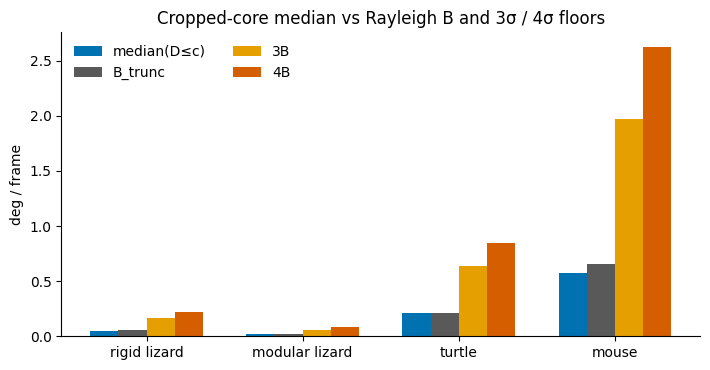

In [8]:
# Operating cutoff: step-3 CUTOFFS if you set them, else GoF, else shape argmin.
if "CUTOFFS" in globals():
    OPERATING_C = dict(CUTOFFS)
elif "GOF_C" in globals():
    OPERATING_C = dict(GOF_C)
else:
    OPERATING_C = dict(ONSET_C)

rows = []
for mount in MOUNTS:
    d = POOLS[mount]
    c = float(OPERATING_C[mount])
    cropped = d[d <= c]
    B = truncated_rayleigh_mle(d, c)
    B_med = float(SCALE.loc[mount, "B_med"])
    row = {
        "mount": mount,
        "c": c,
        "hi_pct_shape": ONSET_HI.get(mount, np.nan),
        "hi_pct_gof": GOF_HI.get(mount, np.nan) if "GOF_HI" in globals() else np.nan,
        "n_cropped": int(cropped.size),
        "frac_kept": cropped.size / d.size if d.size else np.nan,
        "median_cropped": float(np.median(cropped)) if cropped.size else np.nan,
        "B_med": B_med,
        "B_trunc": B,
        "floor_3B": 3.0 * B,
        "floor_4B": 4.0 * B,
        "c / B": c / B if np.isfinite(B) and B > 0 else np.nan,
        "threshold": THRESHOLDS[mount] if THRESHOLDS[mount] is not None else np.nan,
        "threshold / B": np.nan,
        "p_FA": np.nan,
        "log10_p_FA": np.nan,
    }
    if THRESHOLDS[mount] is not None and np.isfinite(B) and B > 0:
        snr = float(THRESHOLDS[mount]) / B
        row["threshold / B"] = snr
        # log10 first: exp(-SNR²/2) underflows to 0 for lizard SNRs (~16–40).
        row["log10_p_FA"] = -0.5 * snr * snr / np.log(10.0)
        row["p_FA"] = float(np.exp(-0.5 * snr * snr))
    rows.append(row)

SUMMARY = pd.DataFrame(rows).set_index("mount")
_show = SUMMARY.copy()
_show["p_FA"] = _show["p_FA"].map(lambda x: f"{x:.3e}" if np.isfinite(x) else "nan")
_show["log10_p_FA"] = _show["log10_p_FA"].map(lambda x: f"{x:.2f}" if np.isfinite(x) else "nan")
display(_show)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
x = np.arange(len(MOUNTS))
w = 0.18
ax.bar(x - 1.5 * w, [SUMMARY.loc[m, "median_cropped"] for m in MOUNTS], w, color="#0072B2", label="median(D≤c)")
ax.bar(x - 0.5 * w, [SUMMARY.loc[m, "B_trunc"] for m in MOUNTS], w, color="0.35", label="B_trunc")
ax.bar(x + 0.5 * w, [SUMMARY.loc[m, "floor_3B"] for m in MOUNTS], w, color="#E69F00", label="3B")
ax.bar(x + 1.5 * w, [SUMMARY.loc[m, "floor_4B"] for m in MOUNTS], w, color="#D55E00", label="4B")
ax.set_xticks(x)
ax.set_xticklabels([META[m][0] for m in MOUNTS])
ax.set_ylabel("deg / frame")
ax.set_title("Cropped-core median vs Rayleigh B and 3σ / 4σ floors")
ax.legend(frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()


## 7. Open a block in the preprocessing GUI

Set `BLOCK_I` (or paste `BLOCK_PATH`) and run. This **does not change the GUI**; it starts the existing app as a separate process on that block so the notebook stays usable. In the GUI, pick a millisecond window with no eye movements, then come back here for the next cell.

`BLOCK` is a `BlockHandle` (same object the GUI uses).


In [4]:
import os
import subprocess
import sys

from eye_tracking_system_tools.analysis.jitter_epochs import load_jitter_registry
from eye_tracking_system_tools.annotation.preprocessing_gui.block_picker import (
    infer_fields_from_block_folder,
)
from eye_tracking_system_tools.annotation.preprocessing_gui.models import BlockHandle

JITTER_SPECS = load_jitter_registry(REPO / "configs" / "jitter_mount_blocks.yaml")
BLOCK_CATALOG = pd.DataFrame(
    [
        {
            "i": i,
            "animal": s.animal,
            "mount": s.mount_type,
            "block": s.block_path.name,
            "path": str(s.block_path),
            "exists": Path(s.block_path).is_dir(),
        }
        for i, s in enumerate(JITTER_SPECS)
    ]
)
display(BLOCK_CATALOG)

# Pick a row from the catalog, or set BLOCK_PATH to any block folder.
BLOCK_I = 0
BLOCK_PATH = Path(BLOCK_CATALOG.loc[BLOCK_I, "path"])
BLOCK_PATH = Path("/Volumes/Data/Nimrod/experiments/PV_228/2026_06_15/block_016")

inferred = infer_fields_from_block_folder(BLOCK_PATH)
if inferred is None:
    raise ValueError(f"Not a block folder: {BLOCK_PATH}")
experiment_path, animal, block_num = inferred
date = (
    BLOCK_PATH.parent.name
    if BLOCK_PATH.parent.name.count("_") == 2 and len(BLOCK_PATH.parent.name) == 10
    else None
)
BLOCK = BlockHandle(
    animal_call=animal,
    experiment_date=date,
    block_num=block_num,
    block_path=BLOCK_PATH,
    path_to_animal_folder=experiment_path,
)
print(BLOCK.display_label)
print("block_path:", BLOCK.block_path)

LAUNCH_GUI = True  # False = only build BLOCK, do not start the app
if LAUNCH_GUI:
    out_dir = BLOCK.analysis_path
    out_dir.mkdir(parents=True, exist_ok=True)
    env = os.environ.copy()
    env["PYTHONPATH"] = str(REPO / "src") + os.pathsep + env.get("PYTHONPATH", "")
    GUI_PROC = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "eye_tracking_system_tools.annotation.preprocessing_gui",
            "--experiment-path",
            str(experiment_path),
            "--animal",
            animal,
            "--block",
            block_num,
            "--output",
            str(out_dir),
        ],
        cwd=str(REPO),
        env=env,
    )
    print(f"preprocessing GUI launched (pid={GUI_PROC.pid}). Notebook is still interactive.")


,i,animal,mount,block,path,exists
0,0,PV_106,rigid,block_008,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
1,1,PV_106,rigid,block_009,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
2,2,PV_106,rigid,block_010,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
3,3,PV_106,rigid,block_011,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
4,4,PV_106,rigid,block_012,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
5,5,PV_106,rigid,block_013,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
6,6,PV_106,rigid,block_014,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
7,7,PV_106,rigid,block_015,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
8,8,PV_106,rigid,block_016,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...,True
9,9,PV_126,rigid,block_006,/Volumes/Data-1/Nimrod/experiments/PV_126/2024...,True


PV_228 / 2026_06_15 / block_016
block_path: /Volumes/Data/Nimrod/experiments/PV_228/2026_06_15/block_016
preprocessing GUI launched (pid=32329). Notebook is still interactive.


instantiated block number 016 at Path: /Volumes/Data/Nimrod/experiments/PV_228/2026_06_15/block_016, new OE version
Found the sample rate for block 016 in the xml file, it is 20000 Hz

Extracting meta data from: /Volumes/Data/Nimrod/experiments/PV_228/2026_06_15/block_016/oe_files/PV228_d3t7_humter2026-06-15_14-49-54/Record Node 106...
Analog channel numbers contain duplicates!!! Reordering numbers serially.

Extracting time stamp information...

Error!!! Some blocks are missing in recording!!!

Checking integrity of all records in ch1...

Metadata extraction complete.
created the .oe_rec attribute as an open ephys recording obj with get_data functionality (standalone mode, no metadata file)
retrieving zertoh sample number for block 016
got it!


## 8. Quiet-window Euclidean distances from the open block

After you have a no-movement interval from the GUI, set `T0_MS` / `T1_MS` (and `EYE`) and run. This reloads Kerr traces from `BLOCK`, keeps samples whose midpoint time is inside the window, and plots \(D=\mathrm{hypot}(\Delta\phi,\Delta\theta)\). Overlay is a Rayleigh fit on **this window only** — a check against the pooled \(B\) from steps 1–6.


[PV_228_block_016] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)
L: 290 steps in [270832, 275651] ms
L: 836 steps in [280781, 294756] ms
L: 622 steps in [306957, 317795] ms
L: 273 steps in [356120, 360663] ms
L: 783 steps in [366914, 379949] ms
  L: 2804 steps total across 5 quiet segments.
R: 290 steps in [270832, 275651] ms
R: 839 steps in [280781, 294756] ms
R: 651 steps in [306957, 317795] ms
R: 273 steps in [356120, 360663] ms
R: 783 steps in [366914, 379949] ms
  R: 2836 steps total across 5 quiet segments.
n=5640  median=0.1135


n           5640.000000
median_D       0.113495
B_med          0.096394
floor_3B       0.289181
floor_4B       0.385574
Name: quiet_window, dtype: float64

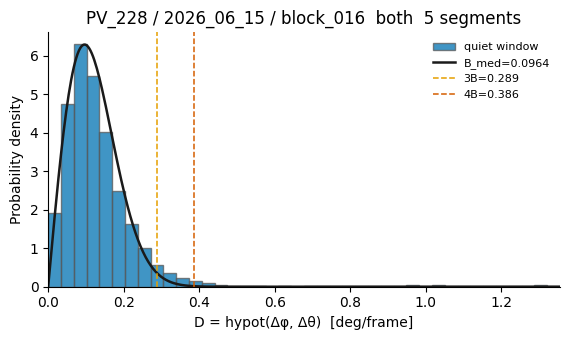

In [5]:
# Multiple quiet segments can be specified as a list of (T0_MS, T1_MS) tuples.
# For a single segment, just use [(T0_MS, T1_MS)].
QUIET_SEGMENTS = [
    (270832.3, 275651.2),
    (280781.3,294756.1),
    (306956.8,317794.8),
    (356120.4,360663.0),
    (366913.9,379949.3)
    # (3000.0, 5000.0),
    # Add more tuples as needed, e.g. (start_ms, end_ms)
]
EYE = "both"  # "left" | "right" | "both"

from eye_tracking_system_tools.analysis.block_registry import BlockSpec
from eye_tracking_system_tools.analysis.eye_trace_io import load_block_eyes
from eye_tracking_system_tools.analysis.saccade_robustness import interframe_steps
from eye_tracking_system_tools.analysis.rayleigh_core import rayleigh_pdf, rayleigh_scale_from_median

if "BLOCK" not in globals():
    raise RuntimeError("Run the previous cell so BLOCK is defined.")

spec = BlockSpec(
    animal=BLOCK.animal_call,
    block_path=BLOCK.block_path,
    block_num=BLOCK.block_num,
)
loaded = load_block_eyes(spec, log=True)
eyes = []
if EYE in ("left", "both"):
    eyes.append(("L", loaded.left))
if EYE in ("right", "both"):
    eyes.append(("R", loaded.right))

parts = []
for name, df in eyes:
    dang, _dt, mid = interframe_steps(df)
    count_total = 0
    for (T0_MS, T1_MS) in QUIET_SEGMENTS:
        keep = np.isfinite(dang) & np.isfinite(mid) & (mid >= float(T0_MS)) & (mid <= float(T1_MS))
        n_keep = int(np.sum(keep))
        count_total += n_keep
        parts.append(dang[keep])
        print(f"{name}: {n_keep} steps in [{T0_MS:g}, {T1_MS:g}] ms")
    if len(QUIET_SEGMENTS) > 1:
        print(f"  {name}: {count_total} steps total across {len(QUIET_SEGMENTS)} quiet segments.")

WINDOW_D = np.concatenate(parts) if parts else np.array([], dtype=float)
WINDOW_D = WINDOW_D[np.isfinite(WINDOW_D) & (WINDOW_D >= 0)]
med_display = np.median(WINDOW_D) if WINDOW_D.size else np.nan
print(f"n={WINDOW_D.size}  median={med_display:.4g}")

B_win = rayleigh_scale_from_median(WINDOW_D)
xmax = float(np.percentile(WINDOW_D, 99.5)) if WINDOW_D.size else 1.0

fig, ax = plt.subplots(figsize=(5.8, 3.5))
if WINDOW_D.size:
    ax.hist(
        WINDOW_D, bins=40, range=(0.0, xmax), density=True,
        color="#0072B2", edgecolor="0.35", alpha=0.75, label="quiet window",
    )
    xs = np.linspace(0.0, xmax, 400)
    if np.isfinite(B_win) and B_win > 0:
        ax.plot(xs, rayleigh_pdf(xs, B_win), color="0.1", lw=1.8, label=f"B_med={B_win:.3g}")
        ax.axvline(3.0 * B_win, color="#E69F00", ls="--", lw=1.1, label=f"3B={3*B_win:.3g}")
        ax.axvline(4.0 * B_win, color="#D55E00", ls="--", lw=1.1, label=f"4B={4*B_win:.3g}")
ax.set_xlim(0.0, xmax)
ax.set_xlabel("D = hypot(Δφ, Δθ)  [deg/frame]")
ax.set_ylabel("Probability density")
# Human-readable summary of segments for title:
if len(QUIET_SEGMENTS) == 1:
    seg_summary = f"{QUIET_SEGMENTS[0][0]:g}–{QUIET_SEGMENTS[0][1]:g} ms"
else:
    seg_summary = f"{len(QUIET_SEGMENTS)} segments"
ax.set_title(f"{BLOCK.display_label}  {EYE}  {seg_summary}")
ax.legend(fontsize=8, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

WINDOW_FIT = pd.Series(
    {
        "n": int(WINDOW_D.size),
        "median_D": float(np.median(WINDOW_D)) if WINDOW_D.size else np.nan,
        "B_med": B_win,
        "floor_3B": 3.0 * B_win if np.isfinite(B_win) else np.nan,
        "floor_4B": 4.0 * B_win if np.isfinite(B_win) else np.nan,
    },
    name="quiet_window",
)
display(WINDOW_FIT)


## 9. Export quiet-segment noise core

Exports the **currently previewed** segment-pooled core from step 8 into a
self-contained plot bundle under `outputs/review_answers_latest/rayleigh_noise_core/`:

- `plots/rayleigh_noise_core.pdf` — histogram + Rayleigh(`B_med`) + **2B** marker + threshold
- `metadata/rayleigh_noise_core.pkl` — samples, segments, block info, fit numbers
- `metadata/rayleigh_noise_core_summary.yaml` — human-readable SNR table
- `replot.py` — redraw PDF from pickle without reloading Kerr traces

**SNR** = `detection_threshold / (2 × B_med)`, where `2 × B_med` is the 2 axis-σ
noise marker on `D` (same convention as the 3B / 4B floors in step 6).

Run step 8 first. Override `DETECTION_THRESHOLD` if the mount default is wrong;
set `TAG` for a timestamped snapshot folder.

In [ ]:
from eye_tracking_system_tools.analysis.rayleigh_noise_core_export import (
    export_rayleigh_noise_core_window,
)

TAG = ""  # e.g. "2026_09_01" → outputs/review_answers_<TAG>/
RUN = REPO / ("outputs/review_answers_latest" if not TAG else f"outputs/review_answers_{TAG}")
PLOT_ID = "rayleigh_noise_core"
DETECTION_THRESHOLD = None  # None → infer from mount via THRESHOLDS

for _name in ("WINDOW_D", "QUIET_SEGMENTS", "BLOCK", "EYE"):
    if _name not in globals():
        raise RuntimeError(f"{_name} missing; run step 8 first.")

if not WINDOW_D.size:
    raise RuntimeError("WINDOW_D is empty; check QUIET_SEGMENTS in step 8.")

# Mount + threshold from the jitter catalog row for this block.
_block_path = str(BLOCK.block_path)
_match = BLOCK_CATALOG[BLOCK_CATALOG["path"].astype(str) == _block_path]
if _match.empty:
    _mount = ""
    print(f"WARNING: block not in BLOCK_CATALOG; mount/threshold may be wrong.\n  {_block_path}")
else:
    _mount = str(_match.iloc[0]["mount"])
    print(f"mount={_mount}  block={BLOCK.display_label}")

_threshold = DETECTION_THRESHOLD
if _threshold is None and _mount in THRESHOLDS:
    _threshold = THRESHOLDS[_mount]
if _threshold is None:
    print("No detection threshold (turtle or unknown mount); SNR will be nan.")

_color = META[_mount][1] if _mount in META else "#0072B2"
_B = float(WINDOW_FIT["B_med"]) if "WINDOW_FIT" in globals() else None

written = export_rayleigh_noise_core_window(
    RUN,
    d=WINDOW_D,
    quiet_segments=list(QUIET_SEGMENTS),
    block_label=str(BLOCK.display_label),
    block_path=BLOCK.block_path,
    animal=str(BLOCK.animal_call),
    eye=str(EYE),
    mount_type=_mount,
    threshold=_threshold,
    B=_B,
    show=True,
    plot_id=PLOT_ID,
    extra_meta={
        "B_win_from_step8": _B,
        "window_fit": WINDOW_FIT.to_dict() if "WINDOW_FIT" in globals() else {},
    },
)

bundle_dir = RUN / PLOT_ID
print(f"\nWrote bundle: {bundle_dir}")
for name, path in sorted(written.items()):
    print(f"  {name}: {path.relative_to(REPO)}")

import yaml

summary = yaml.safe_load((bundle_dir / "metadata" / "rayleigh_noise_core_summary.yaml").read_text())
display(pd.Series(summary, name="export_summary"))
print(
    f"\nSNR (thr / 2B) = {summary.get('snr_thr_over_2B', float('nan')):.4f}  "
    f"[thr={summary.get('detection_threshold_deg_per_frame')}  "
    f"2B={summary.get('floor_2B'):.4g}  B_med={summary.get('B_med'):.4g}]"
)
print(f"Replot: cd {bundle_dir} && python replot.py")


## 10. Mouse quiet-core audit (S10b)

Auto-seeded windows from the S8 M_002/012 trace (lowest-median 2 s). **Edit the tuples after you inspect the block in the preprocessing GUI.** `LAUNCH_GUI_MOUSE = True` starts the existing GUI on that block (same as step 7). Lab volume must be mounted.

In [7]:
import os
import subprocess
import sys

from eye_tracking_system_tools.annotation.preprocessing_gui.block_picker import (
    infer_fields_from_block_folder,
)
from eye_tracking_system_tools.annotation.preprocessing_gui.models import BlockHandle

# Unverified auto-seeds from the S8 M_002/012 trace (edit after GUI).
QUIET_SEGMENTS_MOUSE = [
    (271849.4, 279775.1),
    (348573.8, 364667.8),
    (890690.2, 909981.9),
    (279871.1, 270840.0)
]
MOUSE_BLOCK_PATH = Path("/Volumes/Data/Nimrod/experiments/M_002/2026_07_28/block_012")
LAUNCH_GUI_MOUSE = False

inferred_m = infer_fields_from_block_folder(MOUSE_BLOCK_PATH)
if inferred_m is None:
    print(f"Mouse block not on disk: {MOUSE_BLOCK_PATH}\nEdit QUIET_SEGMENTS_MOUSE anyway; export cell needs the volume.")
    BLOCK_MOUSE = None
else:
    experiment_path_m, animal_m, block_num_m = inferred_m
    date_m = MOUSE_BLOCK_PATH.parent.name if len(MOUSE_BLOCK_PATH.parent.name) == 10 else None
    BLOCK_MOUSE = BlockHandle(
        animal_call=animal_m,
        experiment_date=date_m,
        block_num=block_num_m,
        block_path=MOUSE_BLOCK_PATH,
        path_to_animal_folder=experiment_path_m,
    )
    print(BLOCK_MOUSE.display_label, BLOCK_MOUSE.block_path)
    if LAUNCH_GUI_MOUSE:
        out_dir_m = BLOCK_MOUSE.analysis_path
        out_dir_m.mkdir(parents=True, exist_ok=True)
        env = os.environ.copy()
        env["PYTHONPATH"] = str(REPO / "src") + os.pathsep + env.get("PYTHONPATH", "")
        GUI_PROC_MOUSE = subprocess.Popen(
            [
                sys.executable,
                "-m",
                "eye_tracking_system_tools.annotation.preprocessing_gui",
                "--experiment-path",
                str(experiment_path_m),
                "--animal",
                animal_m,
                "--block",
                block_num_m,
                "--output",
                str(out_dir_m),
            ],
            cwd=str(REPO),
            env=env,
        )
        print(f"preprocessing GUI launched for mouse (pid={GUI_PROC_MOUSE.pid})")


M_002 / 2026_07_28 / block_012 /Volumes/Data/Nimrod/experiments/M_002/2026_07_28/block_012


## 11. Turtle quiet-core audit (S10c)

Auto-seeded windows from the S8 T_18/001 trace. Edit after the GUI. Turtle has **no** detection threshold → SNR omitted on export.

In [ ]:
QUIET_SEGMENTS_TURTLE = [
    (230822.6, 240723.8),
    (241645.8, 244576.2),
    (352584.8, 356664.0),
    (393497.5, 398988.3),
]
TURTLE_BLOCK_PATH = Path("/Volumes/Data/Nimrod/experiments/T_18/block_001")
LAUNCH_GUI_TURTLE = False

inferred_t = infer_fields_from_block_folder(TURTLE_BLOCK_PATH)
if inferred_t is None:
    print(f"Turtle block not on disk: {TURTLE_BLOCK_PATH}")
    BLOCK_TURTLE = None
else:
    experiment_path_t, animal_t, block_num_t = inferred_t
    date_t = TURTLE_BLOCK_PATH.parent.name if len(TURTLE_BLOCK_PATH.parent.name) == 10 else None
    BLOCK_TURTLE = BlockHandle(
        animal_call=animal_t,
        experiment_date=date_t,
        block_num=block_num_t,
        block_path=TURTLE_BLOCK_PATH,
        path_to_animal_folder=experiment_path_t,
    )
    print(BLOCK_TURTLE.display_label, BLOCK_TURTLE.block_path)
    if LAUNCH_GUI_TURTLE:
        out_dir_t = BLOCK_TURTLE.analysis_path
        out_dir_t.mkdir(parents=True, exist_ok=True)
        env = os.environ.copy()
        env["PYTHONPATH"] = str(REPO / "src") + os.pathsep + env.get("PYTHONPATH", "")
        GUI_PROC_TURTLE = subprocess.Popen(
            [
                sys.executable,
                "-m",
                "eye_tracking_system_tools.annotation.preprocessing_gui",
                "--experiment-path",
                str(experiment_path_t),
                "--animal",
                animal_t,
                "--block",
                block_num_t,
                "--output",
                str(out_dir_t),
            ],
            cwd=str(REPO),
            env=env,
        )
        print(f"preprocessing GUI launched for turtle (pid={GUI_PROC_TURTLE.pid})")


T_18 / block_001 /Volumes/Data/Nimrod/experiments/T_18/block_001


## 12. Export audited mouse + turtle quiet-cores (S10b / S10c)

Uses `QUIET_SEGMENTS_MOUSE` / `QUIET_SEGMENTS_TURTLE` from the cells above (after you edit them). Loads Kerr traces from the block (not the 80 s S8 pickle). Writes `outputs/review_answers_latest/rayleigh_noise_core_{mouse,turtle}/`. Then re-run `scripts/aggregate_supp_pdf_materials.py` to refresh S10.

[M_002_block_012] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)
mouse n= 5204 median= 0.3052465091552875


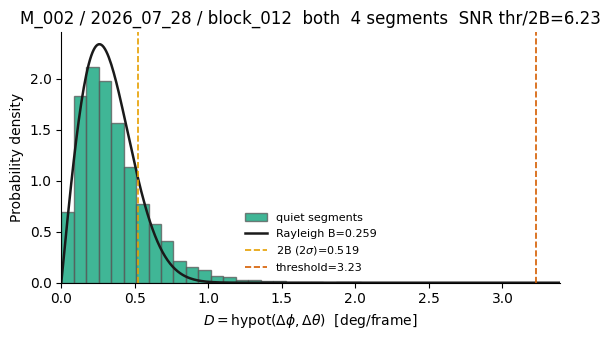

{'rayleigh_noise_core.pdf': 'outputs/review_answers_latest/rayleigh_noise_core_mouse/plots/rayleigh_noise_core.pdf', 'rayleigh_noise_core.pkl': 'outputs/review_answers_latest/rayleigh_noise_core_mouse/metadata/rayleigh_noise_core.pkl', 'rayleigh_noise_core_summary.yaml': 'outputs/review_answers_latest/rayleigh_noise_core_mouse/metadata/rayleigh_noise_core_summary.yaml', 'params.yaml': 'outputs/review_answers_latest/rayleigh_noise_core_mouse/metadata/params.yaml', 'replot.py': 'outputs/review_answers_latest/rayleigh_noise_core_mouse/replot.py'}
[T_18_block_001] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)
turtle n= 35870 median= 0.2045329082429381


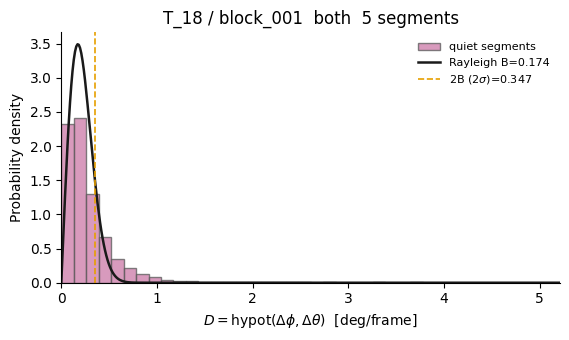

{'rayleigh_noise_core.pdf': 'outputs/review_answers_latest/rayleigh_noise_core_turtle/plots/rayleigh_noise_core.pdf', 'rayleigh_noise_core.pkl': 'outputs/review_answers_latest/rayleigh_noise_core_turtle/metadata/rayleigh_noise_core.pkl', 'rayleigh_noise_core_summary.yaml': 'outputs/review_answers_latest/rayleigh_noise_core_turtle/metadata/rayleigh_noise_core_summary.yaml', 'params.yaml': 'outputs/review_answers_latest/rayleigh_noise_core_turtle/metadata/params.yaml', 'replot.py': 'outputs/review_answers_latest/rayleigh_noise_core_turtle/replot.py'}


In [10]:
from eye_tracking_system_tools.analysis.block_registry import BlockSpec
from eye_tracking_system_tools.analysis.eye_trace_io import load_block_eyes
from eye_tracking_system_tools.analysis.rayleigh_noise_core_export import (
    export_quiet_core_from_trace_pickle,
    export_rayleigh_noise_core_window,
)
from eye_tracking_system_tools.analysis.saccade_robustness import interframe_steps

S10_RUN = REPO / "outputs/review_answers_latest"
TRACE_ROOT = REPO / "outputs/review_answers_finely_tuned_species_traces_20260818_10_21"


def _d_from_block(block: BlockHandle, segments: list[tuple[float, float]], eye: str = "both"):
    spec = BlockSpec(animal=block.animal_call, block_path=block.block_path, block_num=block.block_num)
    loaded = load_block_eyes(spec, log=True)
    eyes = []
    if eye in ("left", "both"):
        eyes.append(loaded.left)
    if eye in ("right", "both"):
        eyes.append(loaded.right)
    parts = []
    for df in eyes:
        dang, _dt, mid = interframe_steps(df)
        for t0, t1 in segments:
            keep = np.isfinite(dang) & np.isfinite(mid) & (mid >= float(t0)) & (mid <= float(t1))
            parts.append(dang[keep])
    d = np.concatenate(parts) if parts else np.array([], dtype=float)
    return d[np.isfinite(d) & (d >= 0)]


jobs = []
if BLOCK_MOUSE is not None:
    jobs.append(("mouse", BLOCK_MOUSE, QUIET_SEGMENTS_MOUSE, THRESHOLDS.get("mouse"), "#009E73"))
else:
    print("Skip mouse Kerr export: BLOCK_MOUSE missing — unverified auto-seed from S8 pickle")
    pkl = TRACE_ROOT / "trace_mouse" / "metadata" / "trace_series.pkl"
    if pkl.is_file():
        print(export_quiet_core_from_trace_pickle(
            pkl, S10_RUN, mount_type="mouse", threshold=THRESHOLDS.get("mouse"),
            color="#009E73", plot_id="rayleigh_noise_core_mouse", show=True,
        ))
if BLOCK_TURTLE is not None:
    jobs.append(("turtle", BLOCK_TURTLE, QUIET_SEGMENTS_TURTLE, THRESHOLDS.get("turtle"), "#CC79A7"))
else:
    print("Skip turtle Kerr export: BLOCK_TURTLE missing — unverified auto-seed from S8 pickle")
    pkl = TRACE_ROOT / "trace_turtle" / "metadata" / "trace_series.pkl"
    if pkl.is_file():
        print(export_quiet_core_from_trace_pickle(
            pkl, S10_RUN, mount_type="turtle", threshold=THRESHOLDS.get("turtle"),
            color="#CC79A7", plot_id="rayleigh_noise_core_turtle", show=True,
        ))

for species, block, segs, thr, color in jobs:
    d = _d_from_block(block, segs)
    print(species, "n=", d.size, "median=", np.median(d) if d.size else np.nan)
    written = export_rayleigh_noise_core_window(
        S10_RUN,
        d=d,
        quiet_segments=list(segs),
        block_label=str(block.display_label),
        block_path=str(block.block_path),
        animal=block.animal_call,
        eye="both",
        mount_type=species,
        threshold=thr,
        color=color,
        show=True,
        plot_id=f"rayleigh_noise_core_{species}",
        extra_meta={"quiet_rule": "GUI-audited (notebook cells 10–11)"},
    )
    print({k: str(v.relative_to(REPO)) for k, v in written.items() if hasattr(v, "relative_to")})
